# Lumbar ultrasound segmentation — two-subject U-Net evaluation

This notebook extends the Subject 8 baseline with **Subject 9 (`Sub9_data`)** and performs a strict two-fold, leave-one-subject-out evaluation:

| Fold | Training / validation | Completely held-out test subject |
|---|---|---|
| 1 | Subject 8 | Subject 9 |
| 2 | Subject 9 | Subject 8 |

Within the training subject, the early chronological frames are used for optimization and the final frames for validation, with an unused temporal gap between them. The held-out subject is never used for training, checkpoint selection, learning-rate adjustment, or threshold selection.

The notebook reports per-frame hard Dice, IoU, precision, recall, empty-mask behavior, HD95 and ASSD in millimetres, plus moving-block bootstrap confidence intervals. Results from only two people are still preliminary, but this is a valid first test of cross-subject generalization.

## 1. Environment and reproducibility

Select **GPU** in Kaggle before running: `Settings → Accelerator → GPU`. Mixed precision is enabled only when a GPU is detected. With two GPUs, `MirroredStrategy` uses both devices.

In [1]:
%pip -q install SimpleITK

Note: you may need to restart the kernel to use updated packages.


In [2]:
import gc
import json
import os
import random
import re
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import SimpleITK as sitk
from scipy import ndimage

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

SEED = 42
os.environ["PYTHONHASHSEED"] = str(SEED)
random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)

try:
    tf.config.experimental.enable_op_determinism()
except Exception as exc:
    print("Deterministic TensorFlow operations could not be enabled:", exc)

GPUS = tf.config.list_physical_devices("GPU")
if not GPUS:
    raise RuntimeError(
        "No GPU was detected. In Kaggle, open Settings and select a GPU accelerator."
    )

keras.mixed_precision.set_global_policy("mixed_float16")
strategy = tf.distribute.MirroredStrategy() if len(GPUS) > 1 else tf.distribute.OneDeviceStrategy("/GPU:0")

print("TensorFlow:", tf.__version__)
print("Physical GPUs:", GPUS)
print("Replicas in sync:", strategy.num_replicas_in_sync)
print("Precision policy:", keras.mixed_precision.global_policy())

INFO:tensorflow:Using MirroredStrategy with devices ('/job:localhost/replica:0/task:0/device:GPU:0', '/job:localhost/replica:0/task:0/device:GPU:1')
TensorFlow: 2.20.0
Physical GPUs: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU'), PhysicalDevice(name='/physical_device:GPU:1', device_type='GPU')]
Replicas in sync: 2
Precision policy: <DTypePolicy "mixed_float16">


I0000 00:00:1787649992.835765      57 gpu_device.cc:2020] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 13756 MB memory:  -> device: 0, name: Tesla T4, pci bus id: 0000:00:04.0, compute capability: 7.5
I0000 00:00:1787649992.838761      57 gpu_device.cc:2020] Created device /job:localhost/replica:0/task:0/device:GPU:1 with 13756 MB memory:  -> device: 1, name: Tesla T4, pci bus id: 0000:00:05.0, compute capability: 7.5


## 2. Configuration

The crop and label convention match the original Subject 8 notebook. If the second subject was acquired with a different field of view, the crop-retention diagnostics below will warn you before training.

`SUBJECT_DIRS` may be filled manually, but normally the resolver finds Kaggle's normalized forms of `Sub8_data` and `Sub9_data` automatically.

In [3]:
# Set an entry to an exact Labels directory only if automatic discovery fails.
SUBJECT_DIRS = {
    "Sub8": None,
    "Sub9": None,
}

SUBJECT_ALIASES = {
    "Sub8": ["sub8_data", "sub8-data", "sub8data", "subject8"],
    "Sub9": ["sub9_data", "sub9-data", "sub9data", "subject9"],
}

# Same crop is the default for both subjects: image[y1:y2, x1:x2].
# You may change one subject independently after inspecting the QC overlays.
# Keep crop heights/widths equal across subjects unless you also add resizing.
SUBJECT_CROPS = {
    "Sub8": {"x1": 546, "x2": 949, "y1": 150, "y2": 930},
    "Sub9": {"x1": 546, "x2": 949, "y1": 150, "y2": 930},
}
MULTIPLE = 16

# Leave these as None for automatic subject-wise inference. To override, use
# e.g. {"background": 0, "foreground": 1} for a known binary encoding.
LABEL_ENCODING_OVERRIDE = {
    "Sub8": None,
    "Sub9": None,
}
NORMALIZATION = "fixed_255"  # Reproduces the original baseline.

BASE_FILTERS = 8
PER_REPLICA_BATCH_SIZE = 4
BATCH_SIZE = PER_REPLICA_BATCH_SIZE * strategy.num_replicas_in_sync
MAX_EPOCHS = 35
EARLY_STOPPING_PATIENCE = 8
VALIDATION_FRACTION = 0.20
TEMPORAL_GAP_FRACTION = 0.05

THRESHOLDS = np.round(np.arange(0.10, 0.91, 0.05), 2)
BOOTSTRAP_REPEATS = 2000
BOOTSTRAP_BLOCK_LENGTH = 10

OUTPUT_DIR = Path("/kaggle/working/two_subject_unet_results")
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

print("Global batch size:", BATCH_SIZE)
print("Results directory:", OUTPUT_DIR)

Global batch size: 8
Results directory: /kaggle/working/two_subject_unet_results


## 3. Locate and pair the MetaImage files

Each `N.mhd` image must have a matching `N-labels.mhd` mask in the same `Labels` directory. Frame IDs are sorted numerically.

In [4]:
def normalized_token(value):
    return re.sub(r"[^a-z0-9]", "", str(value).lower())


def looks_like_labels_dir(path):
    if not path.is_dir():
        return False
    images = [p for p in path.glob("*.mhd") if not p.name.endswith("-labels.mhd")]
    labels = list(path.glob("*-labels.mhd"))
    return bool(images and labels)


def resolve_labels_dir(subject_name, explicit_path=None):
    if explicit_path is not None:
        path = Path(explicit_path)
        if not looks_like_labels_dir(path):
            raise FileNotFoundError(f"Invalid Labels directory for {subject_name}: {path}")
        return path

    root = Path("/kaggle/input")
    if not root.exists():
        raise FileNotFoundError("/kaggle/input is unavailable. Run this notebook on Kaggle.")

    aliases = {normalized_token(a) for a in SUBJECT_ALIASES[subject_name]}
    candidates = []
    for path in root.rglob("*"):
        if path.name.lower() != "labels" or not looks_like_labels_dir(path):
            continue
        path_token = normalized_token(path)
        if any(alias in path_token for alias in aliases):
            candidates.append(path)

    candidates = sorted(set(candidates))
    if len(candidates) == 1:
        return candidates[0]
    if not candidates:
        raise FileNotFoundError(
            f"Could not find {subject_name}. Set SUBJECT_DIRS['{subject_name}'] "
            "to its exact Kaggle Labels directory."
        )
    raise RuntimeError(
        f"More than one candidate was found for {subject_name}: {candidates}. "
        "Select the correct one in SUBJECT_DIRS."
    )


def collect_cases(subject_name, labels_dir):
    image_files = [
        p for p in labels_dir.glob("*.mhd")
        if not p.name.endswith("-labels.mhd") and p.stem.isdigit()
    ]
    image_files = sorted(image_files, key=lambda p: int(p.stem))
    cases = []
    missing_labels = []
    for image_path in image_files:
        label_path = labels_dir / f"{image_path.stem}-labels.mhd"
        if not label_path.exists():
            missing_labels.append(image_path.stem)
            continue
        cases.append({
            "subject": subject_name,
            "id": int(image_path.stem),
            "image": image_path,
            "label": label_path,
        })
    if missing_labels:
        raise FileNotFoundError(f"{subject_name} missing labels for frames: {missing_labels[:20]}")
    if not cases:
        raise RuntimeError(f"No paired frames found for {subject_name} in {labels_dir}")
    return cases


labels_dirs = {
    subject: resolve_labels_dir(subject, SUBJECT_DIRS[subject])
    for subject in SUBJECT_DIRS
}
all_cases = {
    subject: collect_cases(subject, labels_dir)
    for subject, labels_dir in labels_dirs.items()
}

for subject in all_cases:
    ids = [c["id"] for c in all_cases[subject]]
    print(f"{subject}: {labels_dirs[subject]}")
    print(f"  {len(ids)} paired frames; ID range {ids[0]}–{ids[-1]}")

Sub8: /kaggle/input/datasets/amitismirabedini/sub8-data/Labels
  308 paired frames; ID range 0–307
Sub9: /kaggle/input/datasets/amitismirabedini/sub9-data/Labels
  356 paired frames; ID range 0–355


In [5]:
def determine_subject_label_encoding(subject, cases):
    observed = set()
    for case in cases:
        label = np.squeeze(sitk.GetArrayFromImage(sitk.ReadImage(str(case["label"]))))
        observed.update(np.unique(label).tolist())

    observed = sorted(observed)
    override = LABEL_ENCODING_OVERRIDE[subject]
    if override is not None:
        background = override["background"]
        foreground = override["foreground"]
        allowed = {background, foreground}
        unexpected = set(observed) - allowed
        if unexpected:
            raise ValueError(
                f"{subject}: override {override} does not cover observed values {observed}."
            )
    else:
        if len(observed) != 2:
            raise ValueError(
                f"{subject}: expected exactly two label values across the full sequence, "
                f"but observed {observed}. Set LABEL_ENCODING_OVERRIDE after verifying "
                "which value represents the target."
            )
        background, foreground = observed[0], observed[1]

    return {
        "background": background,
        "foreground": foreground,
        "observed": observed,
    }


SUBJECT_LABEL_ENCODINGS = {
    subject: determine_subject_label_encoding(subject, cases)
    for subject, cases in all_cases.items()
}

print("Subject-specific label encodings:")
for subject, encoding in SUBJECT_LABEL_ENCODINGS.items():
    print(
        f"  {subject}: observed={encoding['observed']}, "
        f"background={encoding['background']}, foreground={encoding['foreground']}"
    )

Subject-specific label encodings:
  Sub8: observed=[1, 2], background=1, foreground=2
  Sub9: observed=[0, 2], background=0, foreground=2


## 4. Preprocessing and quality control

Images are cropped, normalized to `[0,1]`, and reflect-padded to a multiple of 16. Label encodings are detected independently for each subject (for example, Subject 8 may use `1/2` while Subject 9 uses `0/1`), then converted to binary `{0,1}` masks. The code checks geometry, label values, and how much annotated foreground survives the crop.

In [6]:
def pad_to_multiple(image, mask, multiple=16):
    h, w = image.shape
    target_h = int(np.ceil(h / multiple) * multiple)
    target_w = int(np.ceil(w / multiple) * multiple)
    pad_h, pad_w = target_h - h, target_w - w
    pad_top, pad_left = pad_h // 2, pad_w // 2
    pads = (
        (pad_top, pad_h - pad_top),
        (pad_left, pad_w - pad_left),
    )
    image = np.pad(image, pads, mode="reflect")
    mask = np.pad(mask, pads, mode="constant", constant_values=0)
    return image, mask


def normalize_ultrasound(image):
    image = image.astype(np.float32)
    if NORMALIZATION == "fixed_255":
        if image.min() < 0 or image.max() > 255:
            warnings.warn(
                f"Observed intensity range [{image.min()}, {image.max()}] outside [0,255]. "
                "Consider changing NORMALIZATION after checking both subjects."
            )
        return np.clip(image / 255.0, 0.0, 1.0)
    if NORMALIZATION == "percentile":
        lo, hi = np.percentile(image, [1, 99])
        return np.clip((image - lo) / max(hi - lo, 1e-6), 0.0, 1.0)
    raise ValueError(f"Unknown normalization: {NORMALIZATION}")


def read_and_preprocess(case, return_qc=False):
    image_itk = sitk.ReadImage(str(case["image"]))
    label_itk = sitk.ReadImage(str(case["label"]))
    image = np.squeeze(sitk.GetArrayFromImage(image_itk))
    label = np.squeeze(sitk.GetArrayFromImage(label_itk))

    if image.ndim != 2 or label.ndim != 2:
        raise ValueError(f"Expected 2D data for {case}; got {image.shape}, {label.shape}")
    if image.shape != label.shape:
        raise ValueError(f"Image/label mismatch for {case}: {image.shape} vs {label.shape}")
    crop = SUBJECT_CROPS[case["subject"]]
    x1, x2, y1, y2 = crop["x1"], crop["x2"], crop["y1"], crop["y2"]
    if not (0 <= y1 < y2 <= image.shape[0] and 0 <= x1 < x2 <= image.shape[1]):
        raise ValueError(
            f"Crop {(y1,y2,x1,x2)} is outside {case['subject']} "
            f"frame {case['id']} shape {image.shape}"
        )

    encoding = SUBJECT_LABEL_ENCODINGS[case["subject"]]
    label_values = np.unique(label)
    unexpected = label_values[
        ~np.isin(label_values, [encoding["background"], encoding["foreground"]])
    ]
    if unexpected.size:
        raise ValueError(f"Unexpected label values {label_values} in {case['label']}")

    full_mask = (label == encoding["foreground"]).astype(np.uint8)
    image_crop = image[y1:y2, x1:x2]
    mask_crop = full_mask[y1:y2, x1:x2]
    full_positive = int(full_mask.sum())
    crop_positive = int(mask_crop.sum())
    retention = 1.0 if full_positive == 0 else crop_positive / full_positive

    image_crop = normalize_ultrasound(image_crop)
    image_crop, mask_crop = pad_to_multiple(image_crop, mask_crop, MULTIPLE)
    spacing_xy = np.asarray(image_itk.GetSpacing()[:2], dtype=np.float32)
    spacing_yx = spacing_xy[::-1]

    qc = {
        "original_shape": image.shape,
        "original_min": float(image.min()),
        "original_max": float(image.max()),
        "crop_retention": retention,
        "spacing_y_mm": float(spacing_yx[0]),
        "spacing_x_mm": float(spacing_yx[1]),
    }
    if return_qc:
        return image_crop, mask_crop, spacing_yx, qc
    return image_crop, mask_crop, spacing_yx

In [7]:
def preload_subject(subject, cases):
    images, masks, spacings, qc_rows = [], [], [], []
    for case in cases:
        image, mask, spacing, qc = read_and_preprocess(case, return_qc=True)
        images.append(image[..., None].astype(np.float16))
        masks.append(mask[..., None].astype(np.uint8))
        spacings.append(spacing)
        qc_rows.append({"subject": subject, "frame_id": case["id"], **qc})

    shapes = {x.shape for x in images}
    if len(shapes) != 1:
        raise ValueError(f"Inconsistent processed shapes in {subject}: {shapes}")
    return {
        "images": np.stack(images),
        "masks": np.stack(masks),
        "spacings": np.stack(spacings),
        "frame_ids": np.asarray([c["id"] for c in cases]),
        "qc": pd.DataFrame(qc_rows),
    }


subject_data = {
    subject: preload_subject(subject, cases)
    for subject, cases in all_cases.items()
}

processed_shapes = {subject: data["images"].shape[1:3] for subject, data in subject_data.items()}
if len(set(processed_shapes.values())) != 1:
    raise ValueError(f"Subjects produce different processed shapes: {processed_shapes}")

MODEL_HEIGHT, MODEL_WIDTH = next(iter(processed_shapes.values()))
qc_table = pd.concat([data["qc"] for data in subject_data.values()], ignore_index=True)

qc_summary = []
for subject, data in subject_data.items():
    fractions = data["masks"].mean(axis=(1, 2, 3))
    qc = data["qc"]
    aggregate_retention = (
        1.0 if np.all(qc["crop_retention"].to_numpy() == 1.0)
        else float(qc["crop_retention"].mean())
    )
    qc_summary.append({
        "subject": subject,
        "frames": len(fractions),
        "processed_shape": f"{MODEL_HEIGHT}×{MODEL_WIDTH}",
        "empty_masks": int((fractions == 0).sum()),
        "mean_foreground_fraction": float(fractions.mean()),
        "minimum_crop_retention": float(qc["crop_retention"].min()),
        "mean_crop_retention": aggregate_retention,
        "intensity_min": float(qc["original_min"].min()),
        "intensity_max": float(qc["original_max"].max()),
    })

qc_summary = pd.DataFrame(qc_summary)
display(qc_summary)

for row in qc_summary.itertuples():
    if row.mean_crop_retention < 0.99:
        warnings.warn(
            f"{row.subject}: the crop retains only {row.mean_crop_retention:.1%} foreground on average. "
            "Inspect the overlays and adjust subject-specific crop coordinates before training."
        )

,subject,frames,processed_shape,empty_masks,mean_foreground_fraction,minimum_crop_retention,mean_crop_retention,intensity_min,intensity_max
0,Sub8,308,784×416,17,0.006527,0.952803,0.997236,16.0,233.0
1,Sub9,356,784×416,30,0.006273,0.953642,0.998045,16.0,234.0


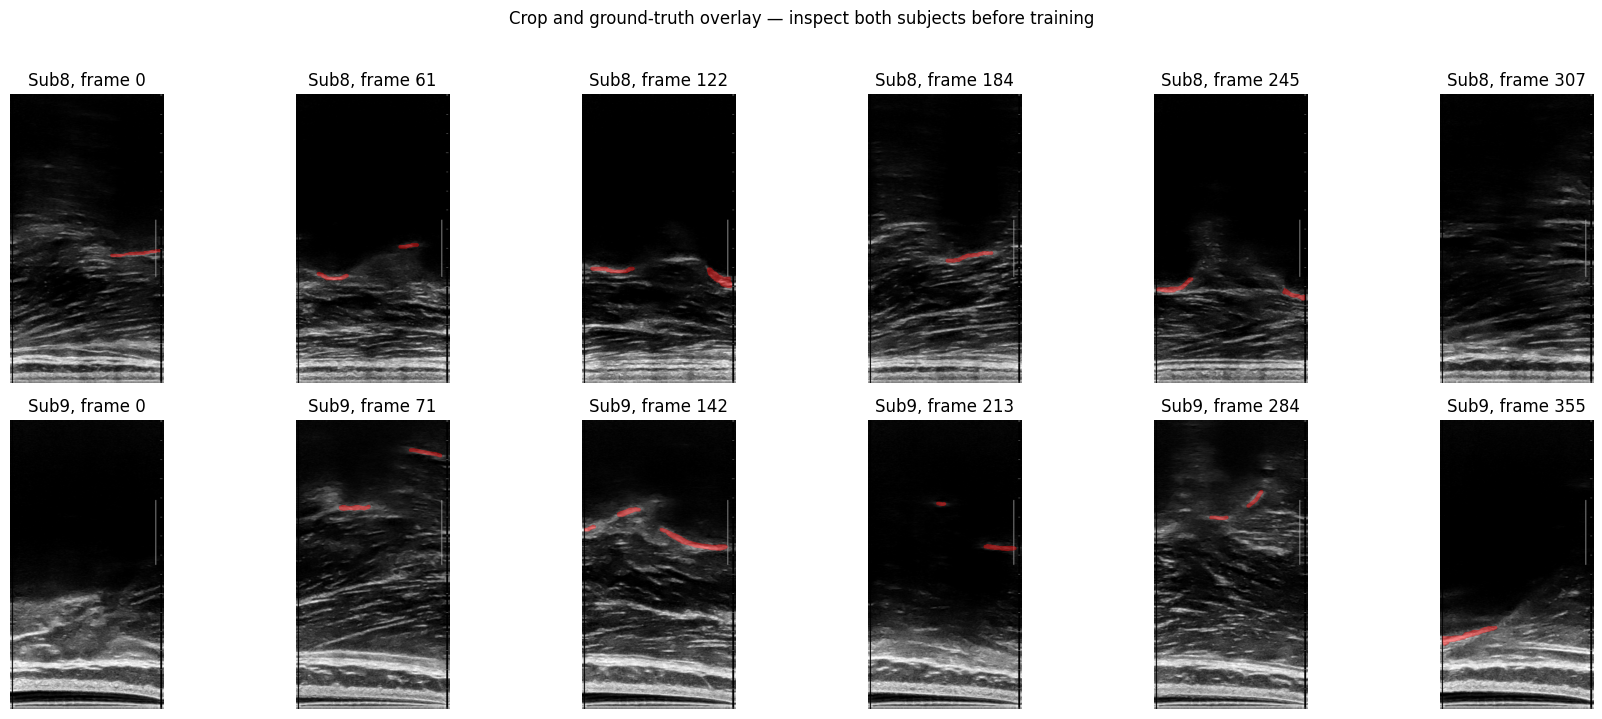

In [8]:
fig, axes = plt.subplots(2, 6, figsize=(18, 7))
for row, (subject, data) in enumerate(subject_data.items()):
    positions = np.linspace(0, len(data["images"]) - 1, 6, dtype=int)
    for col, pos in enumerate(positions):
        image = data["images"][pos, ..., 0].astype(np.float32)
        mask = data["masks"][pos, ..., 0].astype(bool)
        axes[row, col].imshow(image, cmap="gray")
        axes[row, col].imshow(np.ma.masked_where(~mask, mask), cmap="autumn", alpha=0.45)
        axes[row, col].set_title(f"{subject}, frame {data['frame_ids'][pos]}")
        axes[row, col].axis("off")
plt.suptitle("Crop and ground-truth overlay — inspect both subjects before training", y=1.02)
plt.tight_layout()
plt.show()

## 5. Chronological training/validation split

Only the current training subject is split. The held-out subject remains an untouched external test set. A temporal gap is excluded between training and validation to reduce near-duplicate leakage.

In [9]:
def chronological_train_val_indices(n_frames):
    n_val = max(1, int(round(VALIDATION_FRACTION * n_frames)))
    n_gap = max(1, int(round(TEMPORAL_GAP_FRACTION * n_frames)))
    train_end = n_frames - n_gap - n_val
    if train_end <= 0:
        raise ValueError(f"Not enough frames ({n_frames}) for the requested split")
    train_idx = np.arange(0, train_end)
    gap_idx = np.arange(train_end, train_end + n_gap)
    val_idx = np.arange(train_end + n_gap, n_frames)
    return train_idx, gap_idx, val_idx


split_rows = []
for subject, data in subject_data.items():
    train_idx, gap_idx, val_idx = chronological_train_val_indices(len(data["images"]))
    split_rows.append({
        "training_subject": subject,
        "train_n": len(train_idx),
        "train_frame_ids": f"{data['frame_ids'][train_idx[0]]}–{data['frame_ids'][train_idx[-1]]}",
        "gap_n": len(gap_idx),
        "gap_frame_ids": f"{data['frame_ids'][gap_idx[0]]}–{data['frame_ids'][gap_idx[-1]]}",
        "validation_n": len(val_idx),
        "validation_frame_ids": f"{data['frame_ids'][val_idx[0]]}–{data['frame_ids'][val_idx[-1]]}",
    })
display(pd.DataFrame(split_rows))

,training_subject,train_n,train_frame_ids,gap_n,gap_frame_ids,validation_n,validation_frame_ids
0,Sub8,231,0–230,15,231–245,62,246–307
1,Sub9,267,0–266,18,267–284,71,285–355


## 6. GPU data pipeline and lightweight U-Net

Only training batches receive paired horizontal flips and mild intensity augmentation. Masks are never interpolated. The output layer remains float32 for numerical stability under mixed precision.

In [10]:
AUTOTUNE = tf.data.AUTOTUNE


def augment_pair(image, mask):
    do_flip = tf.random.uniform([], seed=SEED) < 0.5
    image = tf.cond(do_flip, lambda: tf.image.flip_left_right(image), lambda: image)
    mask = tf.cond(do_flip, lambda: tf.image.flip_left_right(mask), lambda: mask)
    gain = tf.random.uniform([], 0.90, 1.10, seed=SEED)
    offset = tf.random.uniform([], -0.04, 0.04, seed=SEED + 1)
    image = tf.clip_by_value(tf.cast(image, tf.float32) * gain + offset, 0.0, 1.0)
    return image, tf.cast(mask, tf.float32)


def make_dataset(data, indices=None, training=False):
    if indices is None:
        indices = np.arange(len(data["images"]))
    x = data["images"][indices]
    y = data["masks"][indices]
    ds = tf.data.Dataset.from_tensor_slices((x, y))
    if training:
        ds = ds.shuffle(len(indices), seed=SEED, reshuffle_each_iteration=True)
        ds = ds.map(augment_pair, num_parallel_calls=AUTOTUNE, deterministic=True)
    else:
        ds = ds.map(
            lambda image, mask: (tf.cast(image, tf.float32), tf.cast(mask, tf.float32)),
            num_parallel_calls=AUTOTUNE,
            deterministic=True,
        )
    return ds.batch(BATCH_SIZE, drop_remainder=False).prefetch(AUTOTUNE)

In [11]:
def conv_block(x, filters):
    x = layers.Conv2D(filters, 3, padding="same", use_bias=False)(x)
    x = layers.BatchNormalization(synchronized=(strategy.num_replicas_in_sync > 1))(x)
    x = layers.Activation("relu")(x)
    x = layers.Conv2D(filters, 3, padding="same", use_bias=False)(x)
    x = layers.BatchNormalization(synchronized=(strategy.num_replicas_in_sync > 1))(x)
    return layers.Activation("relu")(x)


def build_small_unet(input_shape=(MODEL_HEIGHT, MODEL_WIDTH, 1), base_filters=8):
    inputs = keras.Input(shape=input_shape)
    c1 = conv_block(inputs, base_filters)
    p1 = layers.MaxPooling2D()(c1)
    c2 = conv_block(p1, base_filters * 2)
    p2 = layers.MaxPooling2D()(c2)
    c3 = conv_block(p2, base_filters * 4)
    p3 = layers.MaxPooling2D()(c3)
    c4 = conv_block(p3, base_filters * 8)
    p4 = layers.MaxPooling2D()(c4)

    bridge = conv_block(p4, base_filters * 16)
    bridge = layers.Dropout(0.20)(bridge)

    u4 = layers.Conv2DTranspose(base_filters * 8, 2, strides=2, padding="same")(bridge)
    c5 = conv_block(layers.Concatenate()([u4, c4]), base_filters * 8)
    u3 = layers.Conv2DTranspose(base_filters * 4, 2, strides=2, padding="same")(c5)
    c6 = conv_block(layers.Concatenate()([u3, c3]), base_filters * 4)
    u2 = layers.Conv2DTranspose(base_filters * 2, 2, strides=2, padding="same")(c6)
    c7 = conv_block(layers.Concatenate()([u2, c2]), base_filters * 2)
    u1 = layers.Conv2DTranspose(base_filters, 2, strides=2, padding="same")(c7)
    c8 = conv_block(layers.Concatenate()([u1, c1]), base_filters)

    outputs = layers.Conv2D(1, 1, activation="sigmoid", dtype="float32")(c8)
    return keras.Model(inputs, outputs, name="small_unet")


SMOOTH = 1e-6


def soft_dice_global(y_true, y_pred):
    y_true = tf.reshape(tf.cast(y_true, tf.float32), [-1])
    y_pred = tf.reshape(tf.cast(y_pred, tf.float32), [-1])
    intersection = tf.reduce_sum(y_true * y_pred)
    return (2.0 * intersection + SMOOTH) / (
        tf.reduce_sum(y_true) + tf.reduce_sum(y_pred) + SMOOTH
    )


def bce_dice_loss(y_true, y_pred):
    bce = tf.reduce_mean(keras.losses.binary_crossentropy(y_true, y_pred))
    return bce + (1.0 - soft_dice_global(y_true, y_pred))


def compile_model():
    with strategy.scope():
        model = build_small_unet(base_filters=BASE_FILTERS)
        model.compile(
            optimizer=keras.optimizers.Adam(learning_rate=1e-3),
            loss=bce_dice_loss,
            metrics=[soft_dice_global],
        )
    return model


preview_model = compile_model()
preview_model.summary()
del preview_model
gc.collect()

Model: "small_unet"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 784, 416,  │          0 │ -                 │
│ (InputLayer)        │ 1)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d (Conv2D)     │ (None, 784, 416,  │         72 │ input_layer[0][0] │
│                     │ 8)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalization │ (None, 784, 416,  │         32 │ conv2d[0][0]      │
│ (BatchNormalizatio… │ 8)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation          │ (None, 784, 416,  │          0 │ batch_normalizat… │
│ (Activation)        │ 8)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_1 (Conv2D)   │ (None, 784, 416,  │        576 │ activation[0][0]  │
│                     │ 8)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 784, 416,  │         32 │ conv2d_1[0][0]    │
│ (BatchNormalizatio… │ 8)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_1        │ (None, 784, 416,  │          0 │ batch_normalizat… │
│ (Activation)        │ 8)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d       │ (None, 392, 208,  │          0 │ activation_1[0][… │
│ (MaxPooling2D)      │ 8)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_2 (Conv2D)   │ (None, 392, 208,  │      1,152 │ max_pooling2d[0]… │
│                     │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 392, 208,  │         64 │ conv2d_2[0][0]    │
│ (BatchNormalizatio… │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_2        │ (None, 392, 208,  │          0 │ batch_normalizat… │
│ (Activation)        │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_3 (Conv2D)   │ (None, 392, 208,  │      2,304 │ activation_2[0][… │
│                     │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 392, 208,  │         64 │ conv2d_3[0][0]    │
│ (BatchNormalizatio… │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_3        │ (None, 392, 208,  │          0 │ batch_normalizat… │
│ (Activation)        │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d_1     │ (None, 196, 104,  │          0 │ activation_3[0][… │
│ (MaxPooling2D)      │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_4 (Conv2D)   │ (None, 196, 104,  │      4,608 │ max_pooling2d_1[… │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 196, 104,  │        128 │ conv2d_4[0][0]  

 Total params: 487,881 (1.86 MB)

 Trainable params: 486,409 (1.86 MB)

 Non-trainable params: 1,472 (5.75 KB)

8213

## 7. Per-frame evaluation functions

Conventions are explicit:

- If ground truth and prediction are both empty, hard Dice and IoU equal 1.
- If exactly one is empty, hard Dice and IoU equal 0.
- Non-empty-target results are always reported separately so empty frames cannot inflate them.
- HD95 and ASSD are reported only when both masks are non-empty.
- The decision threshold is chosen from the training subject's validation frames, never from the held-out subject.

In [12]:
def overlap_metrics(true_mask, pred_mask):
    true_mask = np.asarray(true_mask, dtype=bool)
    pred_mask = np.asarray(pred_mask, dtype=bool)
    tp = int(np.logical_and(true_mask, pred_mask).sum())
    fp = int(np.logical_and(~true_mask, pred_mask).sum())
    fn = int(np.logical_and(true_mask, ~pred_mask).sum())
    true_n = int(true_mask.sum())
    pred_n = int(pred_mask.sum())
    union = tp + fp + fn
    denom = 2 * tp + fp + fn
    dice = 1.0 if denom == 0 else 2 * tp / denom
    iou = 1.0 if union == 0 else tp / union
    precision = np.nan if pred_n == 0 else tp / pred_n
    recall = np.nan if true_n == 0 else tp / true_n
    return {
        "dice": dice,
        "iou": iou,
        "precision": precision,
        "recall": recall,
        "true_pixels": true_n,
        "pred_pixels": pred_n,
        "tp_pixels": tp,
        "fp_pixels": fp,
        "fn_pixels": fn,
        "true_empty": true_n == 0,
        "pred_empty": pred_n == 0,
    }


def surface_distances_mm(true_mask, pred_mask, spacing_yx):
    true_mask = np.asarray(true_mask, dtype=bool)
    pred_mask = np.asarray(pred_mask, dtype=bool)
    if not true_mask.any() or not pred_mask.any():
        return np.nan, np.nan
    structure = ndimage.generate_binary_structure(2, 1)
    true_surface = np.logical_xor(true_mask, ndimage.binary_erosion(true_mask, structure=structure))
    pred_surface = np.logical_xor(pred_mask, ndimage.binary_erosion(pred_mask, structure=structure))
    dt_to_pred = ndimage.distance_transform_edt(~pred_surface, sampling=spacing_yx)
    dt_to_true = ndimage.distance_transform_edt(~true_surface, sampling=spacing_yx)
    distances = np.concatenate([dt_to_pred[true_surface], dt_to_true[pred_surface]])
    return float(np.percentile(distances, 95)), float(distances.mean())


def evaluate_probabilities(subject, data, probabilities, threshold, fold_name):
    rows = []
    for i in range(len(probabilities)):
        truth = data["masks"][i, ..., 0].astype(bool)
        pred = probabilities[i, ..., 0] >= threshold
        row = overlap_metrics(truth, pred)
        hd95, assd = surface_distances_mm(truth, pred, data["spacings"][i])
        rows.append({
            "fold": fold_name,
            "subject": subject,
            "frame_position": i,
            "frame_id": int(data["frame_ids"][i]),
            "threshold": float(threshold),
            **row,
            "hd95_mm": hd95,
            "assd_mm": assd,
        })
    return pd.DataFrame(rows)


def mean_nonempty_dice(masks, probabilities, threshold):
    scores = []
    for truth, probability in zip(masks[..., 0], probabilities[..., 0]):
        truth = truth.astype(bool)
        if not truth.any():
            continue
        scores.append(overlap_metrics(truth, probability >= threshold)["dice"])
    return float(np.mean(scores)) if scores else np.nan


def select_threshold(validation_masks, validation_probabilities):
    rows = [
        {
            "threshold": float(t),
            "validation_nonempty_dice": mean_nonempty_dice(
                validation_masks, validation_probabilities, t
            ),
        }
        for t in THRESHOLDS
    ]
    table = pd.DataFrame(rows)
    best_score = table["validation_nonempty_dice"].max()
    tied = table[np.isclose(table["validation_nonempty_dice"], best_score)]
    # If tied, prefer the value closest to the conventional 0.5 threshold.
    selected = float(tied.iloc[np.argmin(np.abs(tied["threshold"].to_numpy() - 0.5))]["threshold"])
    return selected, table


def moving_block_ci(values, repeats=2000, block_length=10, seed=42):
    values = np.asarray(values, dtype=np.float64)
    n = len(values)
    observed = float(np.nanmean(values))
    if n == 0 or np.all(np.isnan(values)):
        return observed, np.nan, np.nan
    rng = np.random.default_rng(seed)
    estimates = []
    blocks_needed = int(np.ceil(n / block_length))
    for _ in range(repeats):
        starts = rng.integers(0, n, size=blocks_needed)
        indices = np.concatenate([
            (np.arange(start, start + block_length) % n) for start in starts
        ])[:n]
        estimate = np.nanmean(values[indices])
        if np.isfinite(estimate):
            estimates.append(estimate)
    lower, upper = np.percentile(estimates, [2.5, 97.5])
    return observed, float(lower), float(upper)

## 8. Run both subject-level folds

This trains two independent models. Depending on the selected Kaggle GPU, the cell may take a while. Each fold writes its best checkpoint, learning curves, threshold table, per-frame CSV, and prediction examples to the results directory.


fold1_train_Sub8_test_Sub9
INFO:tensorflow:Reduce to /job:localhost/replica:0/task:0/device:CPU:0 then broadcast to ('/job:localhost/replica:0/task:0/device:CPU:0',).
INFO:tensorflow:Reduce to /job:localhost/replica:0/task:0/device:CPU:0 then broadcast to ('/job:localhost/replica:0/task:0/device:CPU:0',).
INFO:tensorflow:Reduce to /job:localhost/replica:0/task:0/device:CPU:0 then broadcast to ('/job:localhost/replica:0/task:0/device:CPU:0',).
INFO:tensorflow:Reduce to /job:localhost/replica:0/task:0/device:CPU:0 then broadcast to ('/job:localhost/replica:0/task:0/device:CPU:0',).
INFO:tensorflow:Reduce to /job:localhost/replica:0/task:0/device:CPU:0 then broadcast to ('/job:localhost/replica:0/task:0/device:CPU:0',).
INFO:tensorflow:Reduce to /job:localhost/replica:0/task:0/device:CPU:0 then broadcast to ('/job:localhost/replica:0/task:0/device:CPU:0',).
INFO:tensorflow:Reduce to /job:localhost/replica:0/task:0/device:CPU:0 then broadcast to ('/job:localhost/replica:0/task:0/device:CP

E0000 00:00:1787650093.851765      57 meta_optimizer.cc:967] layout failed: INVALID_ARGUMENT: Size of values 0 does not match size of permutation 4 @ fanin shape inStatefulPartitionedCall/small_unet_1/dropout_1/stateless_dropout/SelectV2-2-TransposeNHWCToNCHW-LayoutOptimizer


29/29 ━━━━━━━━━━━━━━━━━━━━ 0s 241ms/step - loss: 3.1871 - soft_dice_global: 0.0152INFO:tensorflow:Reduce to /job:localhost/replica:0/task:0/device:CPU:0 then broadcast to ('/job:localhost/replica:0/task:0/device:CPU:0',).
INFO:tensorflow:Reduce to /job:localhost/replica:0/task:0/device:CPU:0 then broadcast to ('/job:localhost/replica:0/task:0/device:CPU:0',).

Epoch 1: val_soft_dice_global improved from None to 0.01291, saving model to /kaggle/working/two_subject_unet_results/fold1_train_Sub8_test_Sub9_best.keras

Epoch 1: finished saving model to /kaggle/working/two_subject_unet_results/fold1_train_Sub8_test_Sub9_best.keras
29/29 ━━━━━━━━━━━━━━━━━━━━ 31s 354ms/step - loss: 3.0243 - soft_dice_global: 0.0148 - val_loss: 3.1669 - val_soft_dice_global: 0.0129 - learning_rate: 0.0010
Epoch 2/35
29/29 ━━━━━━━━━━━━━━━━━━━━ 0s 237ms/step - loss: 2.7235 - soft_dice_global: 0.0171
Epoch 2: val_soft_dice_global improved from 0.01291 to 0.01316, saving model to /kaggle/working/two_subject_unet_re

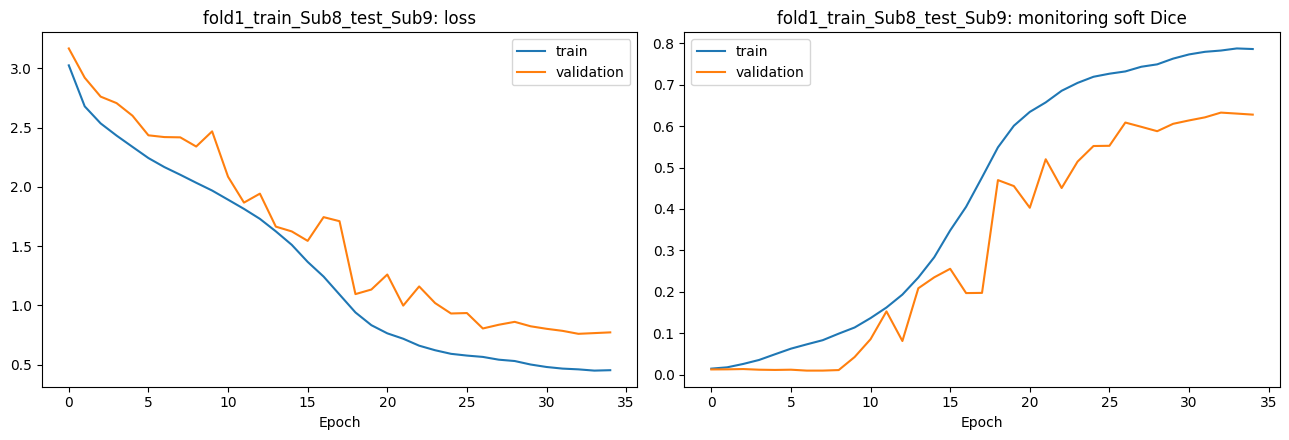

8/8 ━━━━━━━━━━━━━━━━━━━━ 3s 213ms/step
45/45 ━━━━━━━━━━━━━━━━━━━━ 3s 64ms/step
Threshold selected only from Sub8 validation frames: 0.80


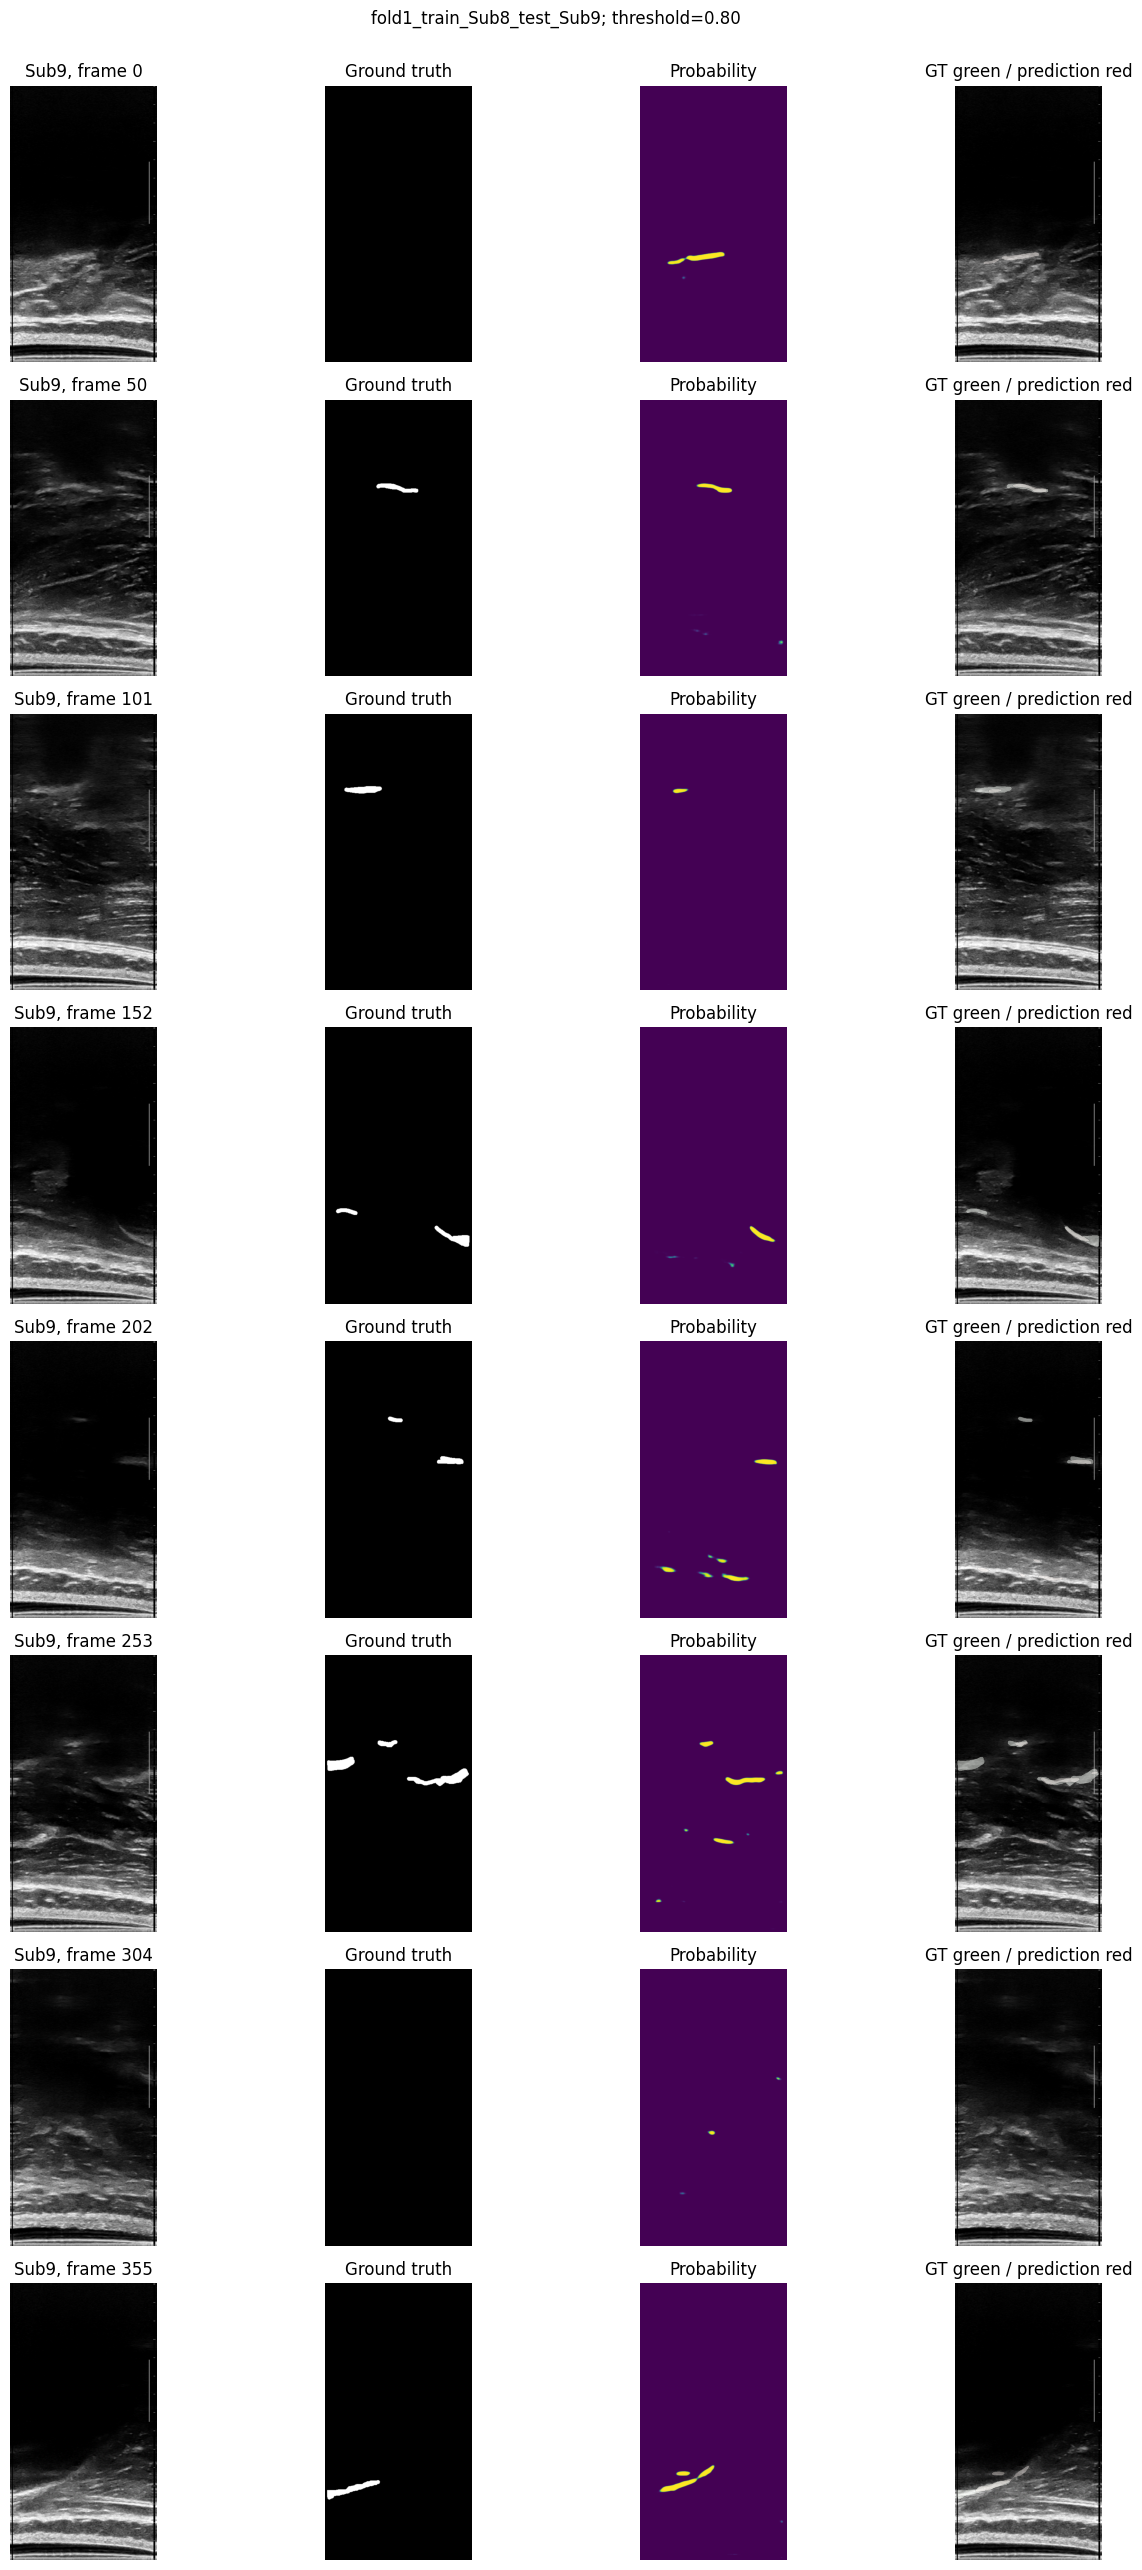


fold2_train_Sub9_test_Sub8
Epoch 1/35
INFO:tensorflow:Collective all_reduce tensors: 1 all_reduces, num_devices = 2, group_size = 2, implementation = CommunicationImplementation.NCCL, num_packs = 1
INFO:tensorflow:Collective all_reduce tensors: 1 all_reduces, num_devices = 2, group_size = 2, implementation = CommunicationImplementation.NCCL, num_packs = 1
INFO:tensorflow:Collective all_reduce tensors: 1 all_reduces, num_devices = 2, group_size = 2, implementation = CommunicationImplementation.NCCL, num_packs = 1
INFO:tensorflow:Collective all_reduce tensors: 1 all_reduces, num_devices = 2, group_size = 2, implementation = CommunicationImplementation.NCCL, num_packs = 1
INFO:tensorflow:Collective all_reduce tensors: 1 all_reduces, num_devices = 2, group_size = 2, implementation = CommunicationImplementation.NCCL, num_packs = 1
INFO:tensorflow:Collective all_reduce tensors: 1 all_reduces, num_devices = 2, group_size = 2, implementation = CommunicationImplementation.NCCL, num_packs = 1
I

E0000 00:00:1787650469.977893      57 meta_optimizer.cc:967] layout failed: INVALID_ARGUMENT: Size of values 0 does not match size of permutation 4 @ fanin shape inStatefulPartitionedCall/small_unet_1/dropout_1/stateless_dropout/SelectV2-2-TransposeNHWCToNCHW-LayoutOptimizer


34/34 ━━━━━━━━━━━━━━━━━━━━ 0s 241ms/step - loss: 3.1496 - soft_dice_global: 0.0134
Epoch 1: val_soft_dice_global improved from None to 0.00935, saving model to /kaggle/working/two_subject_unet_results/fold2_train_Sub9_test_Sub8_best.keras

Epoch 1: finished saving model to /kaggle/working/two_subject_unet_results/fold2_train_Sub9_test_Sub8_best.keras
34/34 ━━━━━━━━━━━━━━━━━━━━ 26s 338ms/step - loss: 3.0286 - soft_dice_global: 0.0135 - val_loss: 3.2334 - val_soft_dice_global: 0.0093 - learning_rate: 0.0010
Epoch 2/35
34/34 ━━━━━━━━━━━━━━━━━━━━ 0s 257ms/step - loss: 2.7885 - soft_dice_global: 0.0133
Epoch 2: val_soft_dice_global improved from 0.00935 to 0.00936, saving model to /kaggle/working/two_subject_unet_results/fold2_train_Sub9_test_Sub8_best.keras

Epoch 2: finished saving model to /kaggle/working/two_subject_unet_results/fold2_train_Sub9_test_Sub8_best.keras
34/34 ━━━━━━━━━━━━━━━━━━━━ 11s 310ms/step - loss: 2.7433 - soft_dice_global: 0.0133 - val_loss: 3.0377 - val_soft_dice_glo

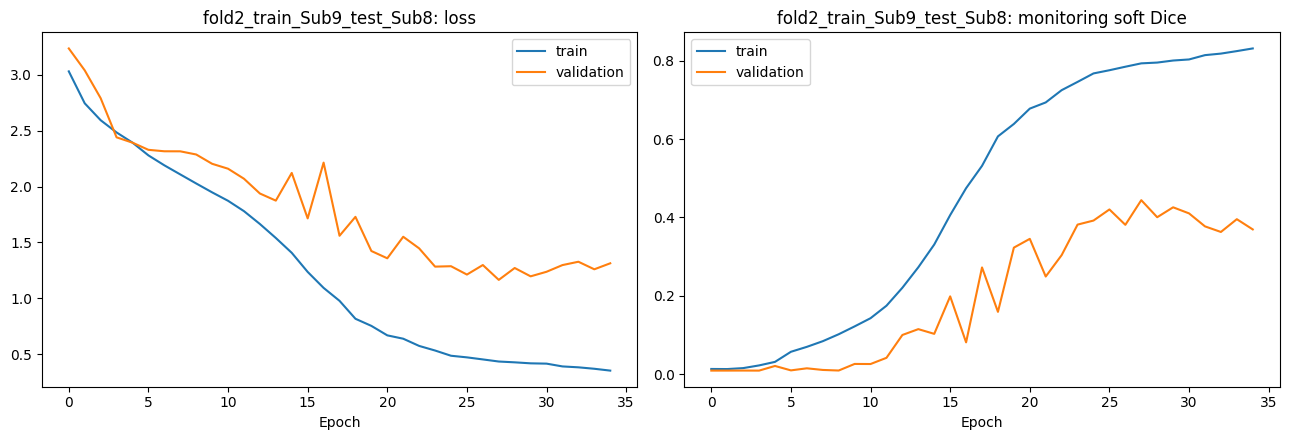

9/9 ━━━━━━━━━━━━━━━━━━━━ 3s 240ms/step
39/39 ━━━━━━━━━━━━━━━━━━━━ 4s 97ms/step
Threshold selected only from Sub9 validation frames: 0.10


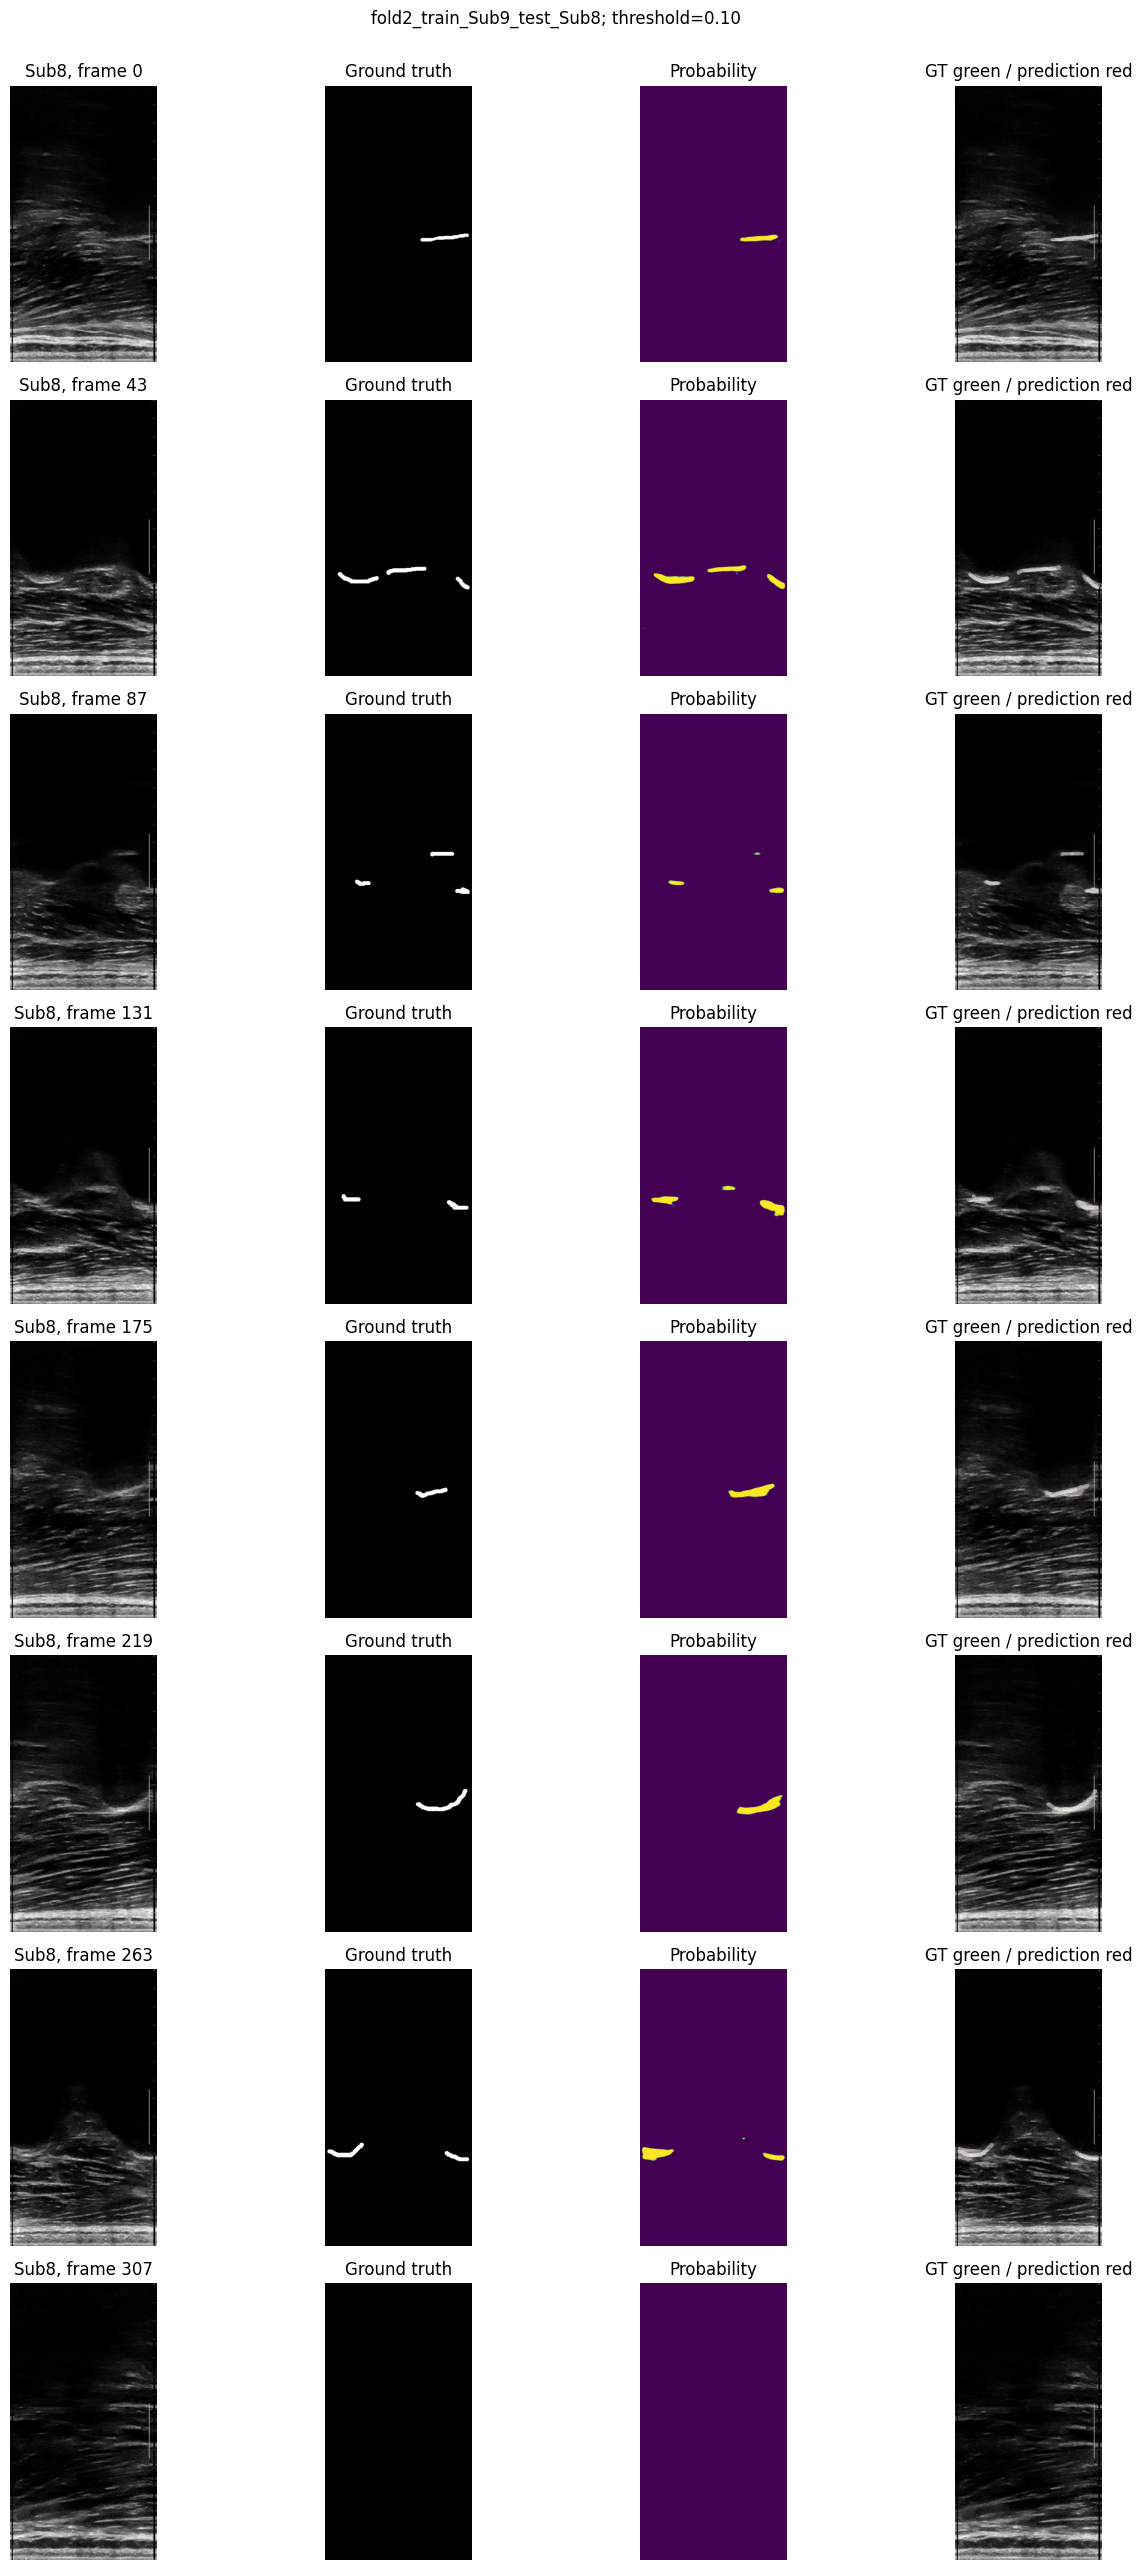

,fold,train_subject,test_subject,train_frames,gap_frames,validation_frames,test_frames,best_epoch,best_validation_soft_dice,selected_threshold
0,fold1_train_Sub8_test_Sub9,Sub8,Sub9,231,15,62,356,33,0.63253,0.8
1,fold2_train_Sub9_test_Sub8,Sub9,Sub8,267,18,71,308,28,0.44414,0.1


In [13]:
def plot_learning_curves(history, fold_name):
    fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))
    axes[0].plot(history.history["loss"], label="train")
    axes[0].plot(history.history["val_loss"], label="validation")
    axes[0].set_title(f"{fold_name}: loss")
    axes[0].set_xlabel("Epoch")
    axes[0].legend()
    axes[1].plot(history.history["soft_dice_global"], label="train")
    axes[1].plot(history.history["val_soft_dice_global"], label="validation")
    axes[1].set_title(f"{fold_name}: monitoring soft Dice")
    axes[1].set_xlabel("Epoch")
    axes[1].legend()
    plt.tight_layout()
    path = OUTPUT_DIR / f"{fold_name}_learning_curves.png"
    plt.savefig(path, dpi=180, bbox_inches="tight")
    plt.show()


def plot_predictions(test_subject, data, probabilities, threshold, fold_name):
    positions = np.linspace(0, len(probabilities) - 1, 8, dtype=int)
    fig, axes = plt.subplots(len(positions), 4, figsize=(14, 3.2 * len(positions)))
    for row, pos in enumerate(positions):
        image = data["images"][pos, ..., 0].astype(np.float32)
        truth = data["masks"][pos, ..., 0].astype(bool)
        probability = probabilities[pos, ..., 0]
        pred = probability >= threshold
        axes[row, 0].imshow(image, cmap="gray")
        axes[row, 0].set_title(f"{test_subject}, frame {data['frame_ids'][pos]}")
        axes[row, 1].imshow(truth, cmap="gray")
        axes[row, 1].set_title("Ground truth")
        axes[row, 2].imshow(probability, cmap="viridis", vmin=0, vmax=1)
        axes[row, 2].set_title("Probability")
        axes[row, 3].imshow(image, cmap="gray")
        axes[row, 3].imshow(np.ma.masked_where(~truth, truth), cmap="Greens", alpha=0.45)
        axes[row, 3].imshow(np.ma.masked_where(~pred, pred), cmap="Reds", alpha=0.35)
        axes[row, 3].set_title("GT green / prediction red")
        for ax in axes[row]:
            ax.axis("off")
    plt.suptitle(f"{fold_name}; threshold={threshold:.2f}", y=1.002)
    plt.tight_layout()
    path = OUTPUT_DIR / f"{fold_name}_prediction_examples.png"
    plt.savefig(path, dpi=180, bbox_inches="tight")
    plt.show()


def run_fold(train_subject, test_subject, fold_number):
    fold_name = f"fold{fold_number}_train_{train_subject}_test_{test_subject}"
    print("\n" + "=" * 90)
    print(fold_name)
    print("=" * 90)

    tf.keras.backend.clear_session()
    gc.collect()
    random.seed(SEED + fold_number)
    np.random.seed(SEED + fold_number)
    tf.random.set_seed(SEED + fold_number)

    train_data = subject_data[train_subject]
    test_data = subject_data[test_subject]
    train_idx, gap_idx, val_idx = chronological_train_val_indices(len(train_data["images"]))

    train_ds = make_dataset(train_data, train_idx, training=True)
    val_ds = make_dataset(train_data, val_idx, training=False)
    test_ds = make_dataset(test_data, training=False)

    model = compile_model()
    checkpoint_path = OUTPUT_DIR / f"{fold_name}_best.keras"
    callbacks = [
        keras.callbacks.ModelCheckpoint(
            checkpoint_path,
            monitor="val_soft_dice_global",
            mode="max",
            save_best_only=True,
            verbose=1,
        ),
        keras.callbacks.EarlyStopping(
            monitor="val_soft_dice_global",
            mode="max",
            patience=EARLY_STOPPING_PATIENCE,
            restore_best_weights=True,
            verbose=1,
        ),
        keras.callbacks.ReduceLROnPlateau(
            monitor="val_loss",
            factor=0.5,
            patience=3,
            min_lr=1e-6,
            verbose=1,
        ),
        keras.callbacks.CSVLogger(OUTPUT_DIR / f"{fold_name}_training_log.csv"),
    ]

    history = model.fit(
        train_ds,
        validation_data=val_ds,
        epochs=MAX_EPOCHS,
        callbacks=callbacks,
        verbose=1,
    )
    plot_learning_curves(history, fold_name)

    validation_probabilities = model.predict(val_ds, verbose=1)
    test_probabilities = model.predict(test_ds, verbose=1)
    selected_threshold, threshold_table = select_threshold(
        train_data["masks"][val_idx], validation_probabilities
    )
    threshold_table.to_csv(OUTPUT_DIR / f"{fold_name}_threshold_search.csv", index=False)
    print(f"Threshold selected only from {train_subject} validation frames: {selected_threshold:.2f}")

    test_metrics_tuned = evaluate_probabilities(
        test_subject, test_data, test_probabilities, selected_threshold, fold_name
    )
    test_metrics_tuned["threshold_type"] = "validation_tuned"
    test_metrics_default = evaluate_probabilities(
        test_subject, test_data, test_probabilities, 0.50, fold_name
    )
    test_metrics_default["threshold_type"] = "fixed_0.50"
    test_metrics = pd.concat([test_metrics_tuned, test_metrics_default], ignore_index=True)
    test_metrics.to_csv(OUTPUT_DIR / f"{fold_name}_per_frame_metrics.csv", index=False)

    plot_predictions(test_subject, test_data, test_probabilities, selected_threshold, fold_name)
    best_epoch = int(np.argmax(history.history["val_soft_dice_global"]) + 1)
    return {
        "fold": fold_name,
        "train_subject": train_subject,
        "test_subject": test_subject,
        "train_frames": len(train_idx),
        "gap_frames": len(gap_idx),
        "validation_frames": len(val_idx),
        "test_frames": len(test_data["images"]),
        "best_epoch": best_epoch,
        "best_validation_soft_dice": float(np.max(history.history["val_soft_dice_global"])),
        "selected_threshold": selected_threshold,
    }, test_metrics


fold_definitions = [("Sub8", "Sub9"), ("Sub9", "Sub8")]
fold_metadata = []
fold_metric_tables = []

for fold_number, (train_subject, test_subject) in enumerate(fold_definitions, start=1):
    metadata, metrics = run_fold(train_subject, test_subject, fold_number)
    fold_metadata.append(metadata)
    fold_metric_tables.append(metrics)

fold_metadata = pd.DataFrame(fold_metadata)
all_frame_metrics = pd.concat(fold_metric_tables, ignore_index=True)
fold_metadata.to_csv(OUTPUT_DIR / "fold_metadata.csv", index=False)
all_frame_metrics.to_csv(OUTPUT_DIR / "all_folds_per_frame_metrics.csv", index=False)
display(fold_metadata)

## 9. Strict result tables and uncertainty

The principal result is the **validation-tuned threshold on non-empty target frames**. The all-frame score is shown alongside it, but must be interpreted with the empty-frame counts. Confidence intervals use a circular moving-block bootstrap with 10 consecutive frames per block to partially account for temporal correlation.

In [14]:
def summarize_fold(group, seed):
    nonempty = group[~group["true_empty"]]
    dice_mean, dice_lo, dice_hi = moving_block_ci(
        np.where(group["true_empty"], np.nan, group["dice"]),
        repeats=BOOTSTRAP_REPEATS,
        block_length=BOOTSTRAP_BLOCK_LENGTH,
        seed=seed,
    )
    iou_mean, iou_lo, iou_hi = moving_block_ci(
        np.where(group["true_empty"], np.nan, group["iou"]),
        repeats=BOOTSTRAP_REPEATS,
        block_length=BOOTSTRAP_BLOCK_LENGTH,
        seed=seed + 100,
    )
    return {
        "fold": group["fold"].iloc[0],
        "test_subject": group["subject"].iloc[0],
        "threshold_type": group["threshold_type"].iloc[0],
        "threshold": group["threshold"].iloc[0],
        "frames_all": len(group),
        "frames_nonempty_gt": len(nonempty),
        "frames_empty_gt": int(group["true_empty"].sum()),
        "dice_all_frames": group["dice"].mean(),
        "dice_nonempty": dice_mean,
        "dice_nonempty_ci95_low": dice_lo,
        "dice_nonempty_ci95_high": dice_hi,
        "iou_all_frames": group["iou"].mean(),
        "iou_nonempty": iou_mean,
        "iou_nonempty_ci95_low": iou_lo,
        "iou_nonempty_ci95_high": iou_hi,
        "precision_nonempty_mean": nonempty["precision"].mean(),
        "recall_nonempty_mean": nonempty["recall"].mean(),
        "hd95_mm_mean_valid_pairs": nonempty["hd95_mm"].replace([np.inf], np.nan).mean(),
        "assd_mm_mean_valid_pairs": nonempty["assd_mm"].replace([np.inf], np.nan).mean(),
        "missed_nonempty_frames": int(((~group["true_empty"]) & group["pred_empty"]).sum()),
        "spurious_predictions_on_empty_frames": int((group["true_empty"] & ~group["pred_empty"]).sum()),
    }


summary_rows = []
for seed_offset, (_, group) in enumerate(
    all_frame_metrics.groupby(["fold", "threshold_type"], sort=False), start=1
):
    summary_rows.append(summarize_fold(group.reset_index(drop=True), SEED + seed_offset))

fold_summary = pd.DataFrame(summary_rows)
fold_summary.to_csv(OUTPUT_DIR / "subject_level_summary.csv", index=False)

principal_summary = fold_summary[fold_summary["threshold_type"] == "validation_tuned"].copy()
display(principal_summary.round(4))

comparison_columns = [
    "fold", "test_subject", "threshold_type", "threshold",
    "dice_nonempty", "iou_nonempty", "dice_all_frames", "iou_all_frames",
]
display(fold_summary[comparison_columns].round(4))

,fold,test_subject,threshold_type,threshold,frames_all,frames_nonempty_gt,frames_empty_gt,dice_all_frames,dice_nonempty,dice_nonempty_ci95_low,...,iou_all_frames,iou_nonempty,iou_nonempty_ci95_low,iou_nonempty_ci95_high,precision_nonempty_mean,recall_nonempty_mean,hd95_mm_mean_valid_pairs,assd_mm_mean_valid_pairs,missed_nonempty_frames,spurious_predictions_on_empty_frames
0,fold1_train_Sub8_test_Sub9,Sub9,validation_tuned,0.8,356,326,30,0.5408,0.5691,0.5199,...,0.4082,0.4242,0.3734,0.4699,0.6097,0.5835,182.5589,56.2018,2,23
2,fold2_train_Sub9_test_Sub8,Sub8,validation_tuned,0.1,308,291,17,0.6239,0.6466,0.6262,...,0.4720,0.4859,0.4629,0.5086,0.5841,0.7785,67.7864,13.3871,0,13


,fold,test_subject,threshold_type,threshold,dice_nonempty,iou_nonempty,dice_all_frames,iou_all_frames
0,fold1_train_Sub8_test_Sub9,Sub9,validation_tuned,0.8,0.5691,0.4242,0.5408,0.4082
1,fold1_train_Sub8_test_Sub9,Sub9,fixed_0.50,0.5,0.5656,0.4202,0.5320,0.3988
2,fold2_train_Sub9_test_Sub8,Sub8,validation_tuned,0.1,0.6466,0.4859,0.6239,0.4720
3,fold2_train_Sub9_test_Sub8,Sub8,fixed_0.50,0.5,0.6534,0.4940,0.6303,0.4797


In [15]:
# Macro-average the two subject-level results: each test subject receives equal weight.
macro_result = pd.DataFrame([{
    "number_of_test_subjects": principal_summary["test_subject"].nunique(),
    "macro_dice_nonempty": principal_summary["dice_nonempty"].mean(),
    "macro_iou_nonempty": principal_summary["iou_nonempty"].mean(),
    "macro_precision_nonempty": principal_summary["precision_nonempty_mean"].mean(),
    "macro_recall_nonempty": principal_summary["recall_nonempty_mean"].mean(),
    "macro_hd95_mm": principal_summary["hd95_mm_mean_valid_pairs"].mean(),
    "macro_assd_mm": principal_summary["assd_mm_mean_valid_pairs"].mean(),
}])
macro_result.to_csv(OUTPUT_DIR / "macro_subject_result.csv", index=False)
display(macro_result.round(4))

,number_of_test_subjects,macro_dice_nonempty,macro_iou_nonempty,macro_precision_nonempty,macro_recall_nonempty,macro_hd95_mm,macro_assd_mm
0,2,0.6078,0.4551,0.5969,0.681,125.1726,34.7944


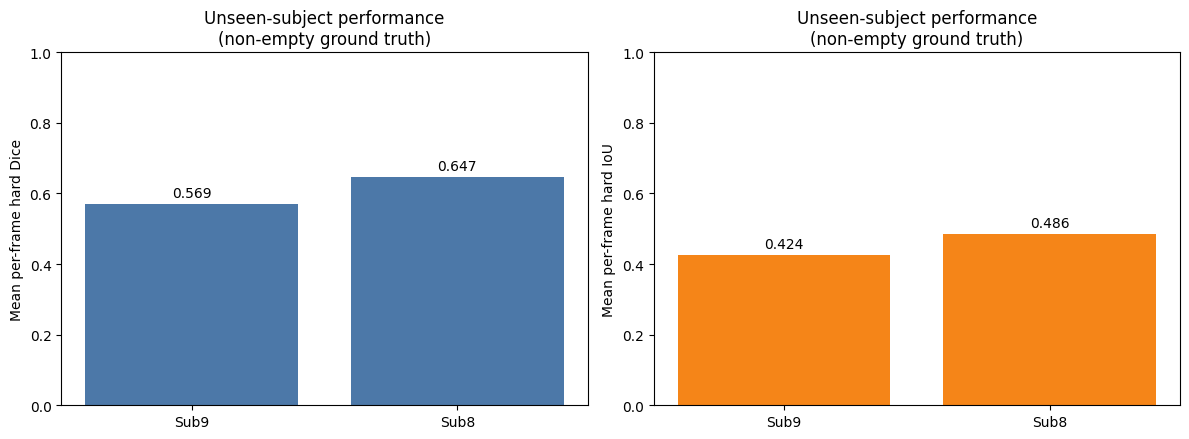

In [16]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))
plot_data = principal_summary.copy()
axes[0].bar(plot_data["test_subject"], plot_data["dice_nonempty"], color="#4C78A8")
axes[0].set_ylim(0, 1)
axes[0].set_ylabel("Mean per-frame hard Dice")
axes[0].set_title("Unseen-subject performance\n(non-empty ground truth)")
axes[1].bar(plot_data["test_subject"], plot_data["iou_nonempty"], color="#F58518")
axes[1].set_ylim(0, 1)
axes[1].set_ylabel("Mean per-frame hard IoU")
axes[1].set_title("Unseen-subject performance\n(non-empty ground truth)")
for ax, metric in zip(axes, ["dice_nonempty", "iou_nonempty"]):
    for i, value in enumerate(plot_data[metric]):
        ax.text(i, value + 0.02, f"{value:.3f}", ha="center")
plt.tight_layout()
plt.savefig(OUTPUT_DIR / "cross_subject_performance.png", dpi=180, bbox_inches="tight")
plt.show()

## 10. Automatically generated supervisor summary

This text deliberately describes the experiment as preliminary. Two subjects permit genuine cross-subject testing, but they are not enough to estimate population-level clinical performance.

In [17]:
def ci_text(row, metric):
    return (
        f"{row[metric]:.3f} "
        f"(95% moving-block bootstrap CI "
        f"{row[metric + '_ci95_low']:.3f}–{row[metric + '_ci95_high']:.3f})"
    )


lines = [
    "Preliminary two-subject lumbar-ultrasound U-Net evaluation",
    "",
    (
        "We evaluated a lightweight 2D U-Net using two leave-one-subject-out folds. "
        "In each fold, one subject supplied chronological training and validation frames, "
        "while the other subject was held out completely for testing. The segmentation "
        "threshold was selected using validation data only."
    ),
    "",
]

for row in principal_summary.itertuples(index=False):
    row = row._asdict()
    lines.append(
        f"Testing on {row['test_subject']}: non-empty-frame Dice "
        f"{ci_text(row, 'dice_nonempty')}, IoU {ci_text(row, 'iou_nonempty')}; "
        f"{row['frames_nonempty_gt']} non-empty and {row['frames_empty_gt']} empty test frames. "
        f"The model missed {row['missed_nonempty_frames']} non-empty frames and produced "
        f"segmentation on {row['spurious_predictions_on_empty_frames']} empty frames."
    )

lines.extend([
    "",
    (
        f"Across the two held-out subjects, the subject-macro mean non-empty Dice was "
        f"{macro_result.loc[0, 'macro_dice_nonempty']:.3f} and macro IoU was "
        f"{macro_result.loc[0, 'macro_iou_nonempty']:.3f}."
    ),
    "",
    (
        "These results provide an initial cross-subject feasibility assessment rather than "
        "a final estimate of generalization. Additional subjects should be evaluated with "
        "the same subject-level separation before drawing clinical conclusions."
    ),
])

supervisor_summary = "\n".join(lines)
print(supervisor_summary)
(OUTPUT_DIR / "supervisor_summary.txt").write_text(supervisor_summary)

config_to_save = {
    "seed": SEED,
    "subject_crops": SUBJECT_CROPS,
    "normalization": NORMALIZATION,
    "subject_label_encodings": SUBJECT_LABEL_ENCODINGS,
    "base_filters": BASE_FILTERS,
    "batch_size": BATCH_SIZE,
    "max_epochs": MAX_EPOCHS,
    "validation_fraction": VALIDATION_FRACTION,
    "temporal_gap_fraction": TEMPORAL_GAP_FRACTION,
    "bootstrap_repeats": BOOTSTRAP_REPEATS,
    "bootstrap_block_length": BOOTSTRAP_BLOCK_LENGTH,
}
(OUTPUT_DIR / "experiment_config.json").write_text(json.dumps(config_to_save, indent=2))

print("\nSaved outputs:")
for path in sorted(OUTPUT_DIR.iterdir()):
    print(" -", path.name)

Preliminary two-subject lumbar-ultrasound U-Net evaluation

We evaluated a lightweight 2D U-Net using two leave-one-subject-out folds. In each fold, one subject supplied chronological training and validation frames, while the other subject was held out completely for testing. The segmentation threshold was selected using validation data only.

Testing on Sub9: non-empty-frame Dice 0.569 (95% moving-block bootstrap CI 0.520–0.614), IoU 0.424 (95% moving-block bootstrap CI 0.373–0.470); 326 non-empty and 30 empty test frames. The model missed 2 non-empty frames and produced segmentation on 23 empty frames.
Testing on Sub8: non-empty-frame Dice 0.647 (95% moving-block bootstrap CI 0.626–0.667), IoU 0.486 (95% moving-block bootstrap CI 0.463–0.509); 291 non-empty and 17 empty test frames. The model missed 0 non-empty frames and produced segmentation on 13 empty frames.

Across the two held-out subjects, the subject-macro mean non-empty Dice was 0.608 and macro IoU was 0.455.

These results

## Interpretation checklist

Before sharing the numbers, confirm all of the following:

1. Both rows of the crop/ground-truth figure show the intended anatomy throughout the sequence.
2. Mean crop retention is close to 100% for both subjects.
3. The learning curves converge without a widening validation gap.
4. The main reported values are `dice_nonempty` and `iou_nonempty`, not only all-frame scores.
5. Prediction overlays are inspected for missed thin structures, systematic offsets, and false positives.
6. The conclusion remains limited to two subjects. When all seven subjects are available, repeat leave-one-subject-out evaluation across all seven folds.

### Inscpecting Subject Format (Sub_26)

In [18]:
from pathlib import Path
import numpy as np

KAGGLE_INPUT = Path("/kaggle/input")

recording_paths = list(
    KAGGLE_INPUT.rglob("URS26_H3_recordings.npy")
)
label_paths = list(
    KAGGLE_INPUT.rglob("URS26_H3_labels.npy")
)

print("Recording candidates:")
for path in recording_paths:
    print(" ", path)

print("\nLabel candidates:")
for path in label_paths:
    print(" ", path)

assert len(recording_paths) == 1, (
    f"Expected one recordings file, found {len(recording_paths)}"
)
assert len(label_paths) == 1, (
    f"Expected one labels file, found {len(label_paths)}"
)

recordings = np.load(
    recording_paths[0],
    mmap_mode="r",
    allow_pickle=False,
)

labels = np.load(
    label_paths[0],
    mmap_mode="r",
    allow_pickle=False,
)


def describe_array(name, array):
    print(f"\n========== {name} ==========")
    print("Path:", recording_paths[0] if name == "recordings" else label_paths[0])
    print("Shape:", array.shape)
    print("Number of dimensions:", array.ndim)
    print("dtype:", array.dtype)
    print("Number of elements:", array.size)
    print("Size on disk approximately:", f"{array.nbytes / 1024**3:.3f} GB")

    sample_size = min(array.size, 1_000_000)
    sample_indices = np.linspace(
        0,
        array.size - 1,
        sample_size,
        dtype=np.int64,
    )
    sample = np.asarray(
        array.reshape(-1)[sample_indices]
    )

    print("Sample minimum:", np.nanmin(sample))
    print("Sample maximum:", np.nanmax(sample))
    print("Sample mean:", np.nanmean(sample))
    print("Sample standard deviation:", np.nanstd(sample))
    print("Contains NaN in sample:", np.isnan(sample).any())


describe_array("recordings", recordings)
describe_array("labels", labels)

print("\nSame shape:", recordings.shape == labels.shape)

Recording candidates:
  /kaggle/input/datasets/amitismirabedini/sub26-data/URS26_H3_recordings.npy

Label candidates:
  /kaggle/input/datasets/amitismirabedini/sub26-data/URS26_H3_labels.npy

========== recordings ==========
Path: /kaggle/input/datasets/amitismirabedini/sub26-data/URS26_H3_recordings.npy
Shape: (4972, 256, 256)
Number of dimensions: 3
dtype: float32
Number of elements: 325844992
Size on disk approximately: 1.214 GB
Sample minimum: 0.0627451
Sample maximum: 0.8627451
Sample mean: 0.09911818
Sample standard deviation: 0.07256714
Contains NaN in sample: False

========== labels ==========
Path: /kaggle/input/datasets/amitismirabedini/sub26-data/URS26_H3_labels.npy
Shape: (4972, 256, 256)
Number of dimensions: 3
dtype: float32
Number of elements: 325844992
Size on disk approximately: 1.214 GB
Sample minimum: 0.0
Sample maximum: 1.0
Sample mean: 0.00012038825
Sample standard deviation: 0.009716601
Contains NaN in sample: False

Same shape: True


In [19]:
def inspect_label_values(array, chunk_size=5_000_000):
    flat = array.reshape(-1)
    discovered = set()

    for start in range(0, flat.size, chunk_size):
        chunk = np.asarray(
            flat[start:start + chunk_size]
        )

        values = np.unique(chunk)
        discovered.update(values.tolist())

        # اگر label ظاهراً continuous باشد، ادامه اسکن مفید نیست.
        if len(discovered) > 32:
            print("More than 32 label values found.")
            print("This may not be a simple binary mask.")
            return sorted(discovered)[:32]

    return sorted(discovered)


label_values = inspect_label_values(labels)
print("All detected label values:", label_values)

More than 32 label values found.
This may not be a simple binary mask.
All detected label values: [0.0, 0.003921568859368563, 0.007843137718737125, 0.0117647061124444, 0.01568627543747425, 0.019607843831181526, 0.0235294122248888, 0.027450980618596077, 0.0313725508749485, 0.03529411926865578, 0.03921568766236305, 0.04313725605607033, 0.0470588244497776, 0.05098039284348488, 0.054901961237192154, 0.05882352963089943, 0.062745101749897, 0.06666667014360428, 0.07058823853731155, 0.07450980693101883, 0.0784313753247261, 0.08235294371843338, 0.08627451211214066, 0.09019608050584793, 0.0941176488995552, 0.09803921729326248, 0.10588235408067703, 0.10980392247438431, 0.11372549086809158, 0.12156862765550613, 0.12941177189350128, 0.13333334028720856]


Squeezed recordings shape: (4972, 256, 256)
Squeezed labels shape: (4972, 256, 256)


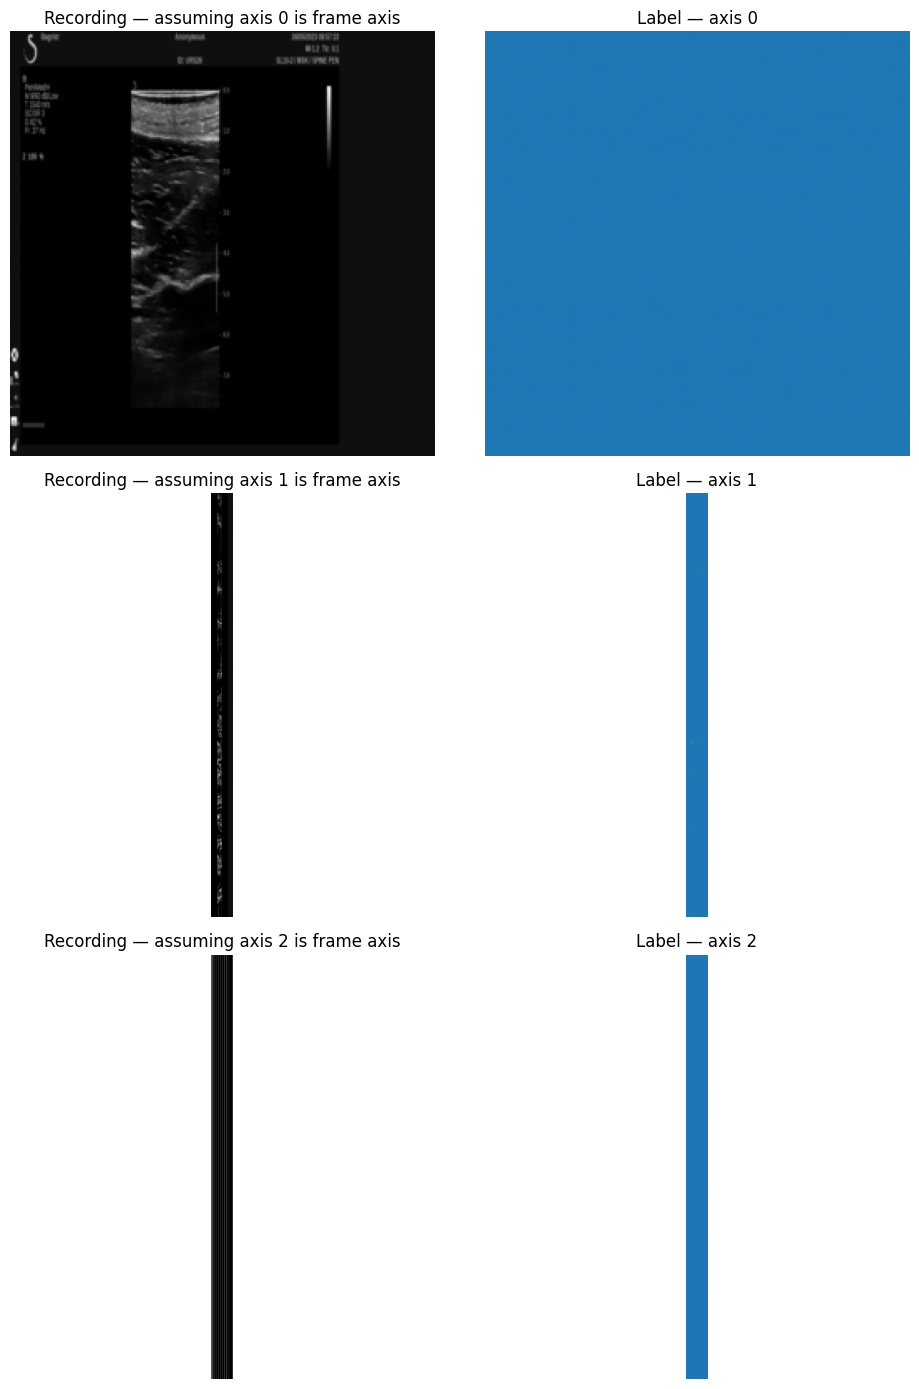

In [20]:
import matplotlib.pyplot as plt

x = np.squeeze(recordings)
y = np.squeeze(labels)

print("Squeezed recordings shape:", x.shape)
print("Squeezed labels shape:", y.shape)

if x.ndim == 3 and x.shape == y.shape:
    fig, axes = plt.subplots(
        3,
        2,
        figsize=(10, 14),
    )

    for axis in range(3):
        position = x.shape[axis] // 2

        image_slice = np.take(
            x,
            position,
            axis=axis,
        )
        label_slice = np.take(
            y,
            position,
            axis=axis,
        )

        axes[axis, 0].imshow(
            image_slice,
            cmap="gray",
        )
        axes[axis, 0].set_title(
            f"Recording — assuming axis {axis} is frame axis"
        )

        axes[axis, 1].imshow(
            label_slice,
            cmap="tab10",
        )
        axes[axis, 1].set_title(
            f"Label — axis {axis}"
        )

        axes[axis, 0].axis("off")
        axes[axis, 1].axis("off")

    plt.tight_layout()
    plt.show()

else:
    print(
        "Automatic 3D visualization was skipped because "
        "the arrays are not matching 3D arrays."
    )

In [21]:
import numpy as np
import pandas as pd

n_frames = labels.shape[0]
chunk_size = 128

thresholds = [0.0, 0.01, 0.10, 0.25, 0.50, 0.75]

pixel_counts = {
    threshold: np.zeros(n_frames, dtype=np.int64)
    for threshold in thresholds
}

frame_maximum = np.zeros(n_frames, dtype=np.float32)
frame_label_sum = np.zeros(n_frames, dtype=np.float64)

# چون مقادیر mask مضرب 1/255 هستند
intensity_histogram = np.zeros(256, dtype=np.int64)

for start in range(0, n_frames, chunk_size):
    end = min(start + chunk_size, n_frames)

    block = np.asarray(
        labels[start:end],
        dtype=np.float32,
    )

    frame_maximum[start:end] = block.max(
        axis=(1, 2)
    )

    frame_label_sum[start:end] = block.sum(
        axis=(1, 2)
    )

    pixel_counts[0.0][start:end] = (
        block > 0
    ).sum(axis=(1, 2))

    for threshold in thresholds[1:]:
        pixel_counts[threshold][start:end] = (
            block >= threshold
        ).sum(axis=(1, 2))

    encoded_values = np.clip(
        np.rint(block * 255),
        0,
        255,
    ).astype(np.uint8)

    intensity_histogram += np.bincount(
        encoded_values.reshape(-1),
        minlength=256,
    )


print("========== Frame-level label statistics ==========")

for threshold in thresholds:
    nonempty_frames = np.count_nonzero(
        pixel_counts[threshold] > 0
    )

    print(
        f"Threshold {threshold:>4}: "
        f"{nonempty_frames}/{n_frames} non-empty frames "
        f"({100 * nonempty_frames / n_frames:.2f}%)"
    )


print("\nMaximum label value across dataset:")
print(frame_maximum.max())

print("\nFrames with maximum label < 0.5:")
print(np.count_nonzero(frame_maximum < 0.5))


histogram_table = pd.DataFrame({
    "uint8_value": np.arange(256),
    "normalized_value": np.arange(256) / 255.0,
    "pixel_count": intensity_histogram,
})

histogram_table = histogram_table[
    histogram_table["pixel_count"] > 0
]

display(histogram_table)

========== Frame-level label statistics ==========
Threshold  0.0: 600/4972 non-empty frames (12.07%)
Threshold 0.01: 600/4972 non-empty frames (12.07%)
Threshold  0.1: 600/4972 non-empty frames (12.07%)
Threshold 0.25: 600/4972 non-empty frames (12.07%)
Threshold  0.5: 600/4972 non-empty frames (12.07%)
Threshold 0.75: 600/4972 non-empty frames (12.07%)

Maximum label value across dataset:
1.0

Frames with maximum label < 0.5:
4372


,uint8_value,normalized_value,pixel_count
0,0,0.000000,325767852
1,1,0.003922,2876
2,2,0.007843,1918
3,3,0.011765,1384
4,4,0.015686,1086
...,...,...,...
251,251,0.984314,772
252,252,0.988235,932
253,253,0.992157,1060
254,254,0.996078,1736


Frames containing labels at threshold 0.5: 600


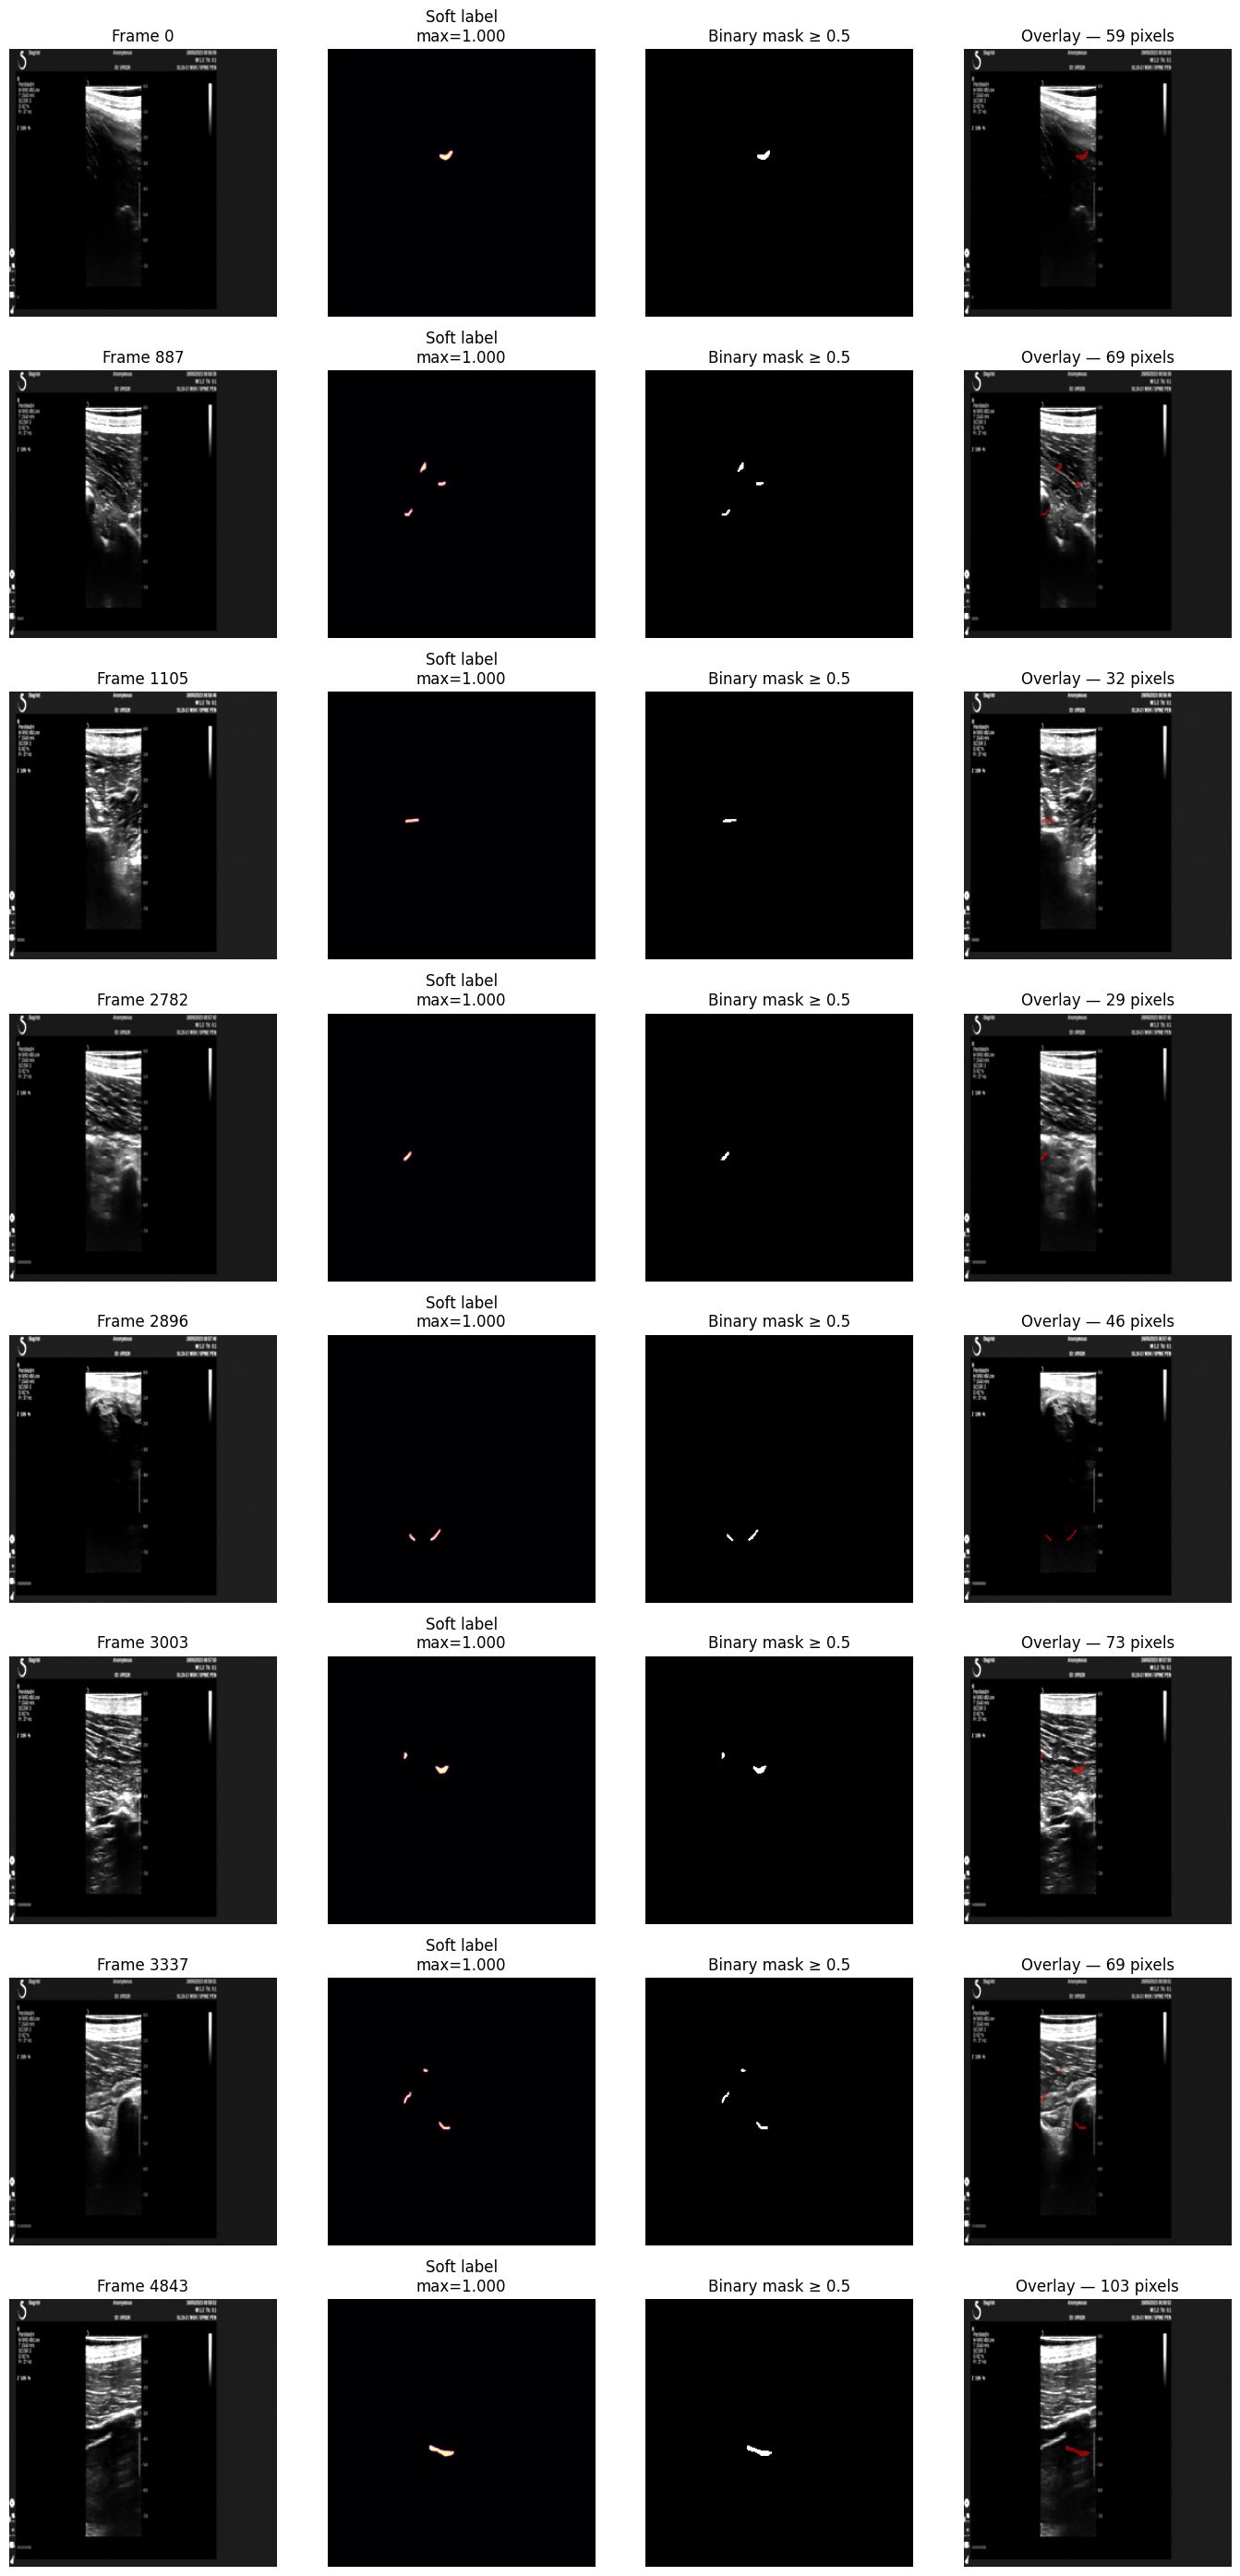

In [22]:
import matplotlib.pyplot as plt
import numpy as np

MASK_THRESHOLD = 0.50

nonempty_indices = np.where(
    pixel_counts[MASK_THRESHOLD] > 0
)[0]

print(
    f"Frames containing labels at threshold {MASK_THRESHOLD}:",
    len(nonempty_indices),
)

if len(nonempty_indices) == 0:
    print(
        "No masks were found at threshold 0.5. "
        "Try threshold 0.1 after inspecting the histogram."
    )

else:
    selected_positions = np.linspace(
        0,
        len(nonempty_indices) - 1,
        min(8, len(nonempty_indices)),
        dtype=int,
    )

    selected_frames = nonempty_indices[
        selected_positions
    ]

    fig, axes = plt.subplots(
        len(selected_frames),
        4,
        figsize=(14, 3.5 * len(selected_frames)),
    )

    if len(selected_frames) == 1:
        axes = axes[None, :]

    for row, frame_index in enumerate(selected_frames):
        image = np.asarray(
            recordings[frame_index],
            dtype=np.float32,
        )

        soft_mask = np.asarray(
            labels[frame_index],
            dtype=np.float32,
        )

        binary_mask = (
            soft_mask >= MASK_THRESHOLD
        )

        image_vmin, image_vmax = np.percentile(
            image,
            [1, 99],
        )

        # Original ultrasound
        axes[row, 0].imshow(
            image,
            cmap="gray",
            vmin=image_vmin,
            vmax=image_vmax,
        )
        axes[row, 0].set_title(
            f"Frame {frame_index}"
        )

        # Soft grayscale label
        axes[row, 1].imshow(
            soft_mask,
            cmap="magma",
            vmin=0,
            vmax=1,
        )
        axes[row, 1].set_title(
            f"Soft label\nmax={soft_mask.max():.3f}"
        )

        # Binary mask
        axes[row, 2].imshow(
            binary_mask,
            cmap="gray",
            vmin=0,
            vmax=1,
        )
        axes[row, 2].set_title(
            f"Binary mask ≥ {MASK_THRESHOLD}"
        )

        # Overlay
        axes[row, 3].imshow(
            image,
            cmap="gray",
            vmin=image_vmin,
            vmax=image_vmax,
        )

        axes[row, 3].imshow(
            np.ma.masked_where(
                ~binary_mask,
                binary_mask,
            ),
            cmap="autumn",
            alpha=0.55,
        )

        axes[row, 3].set_title(
            f"Overlay — {binary_mask.sum()} pixels"
        )

        for axis in axes[row]:
            axis.axis("off")

    plt.tight_layout()
    plt.show()

Selected frames: [  48   49  126  127 3940 3941 3958 3959 4000 4001 4466 4467]
Mask pixel counts: [159 159 213 213 162 162 186 186 167 167 228 228]


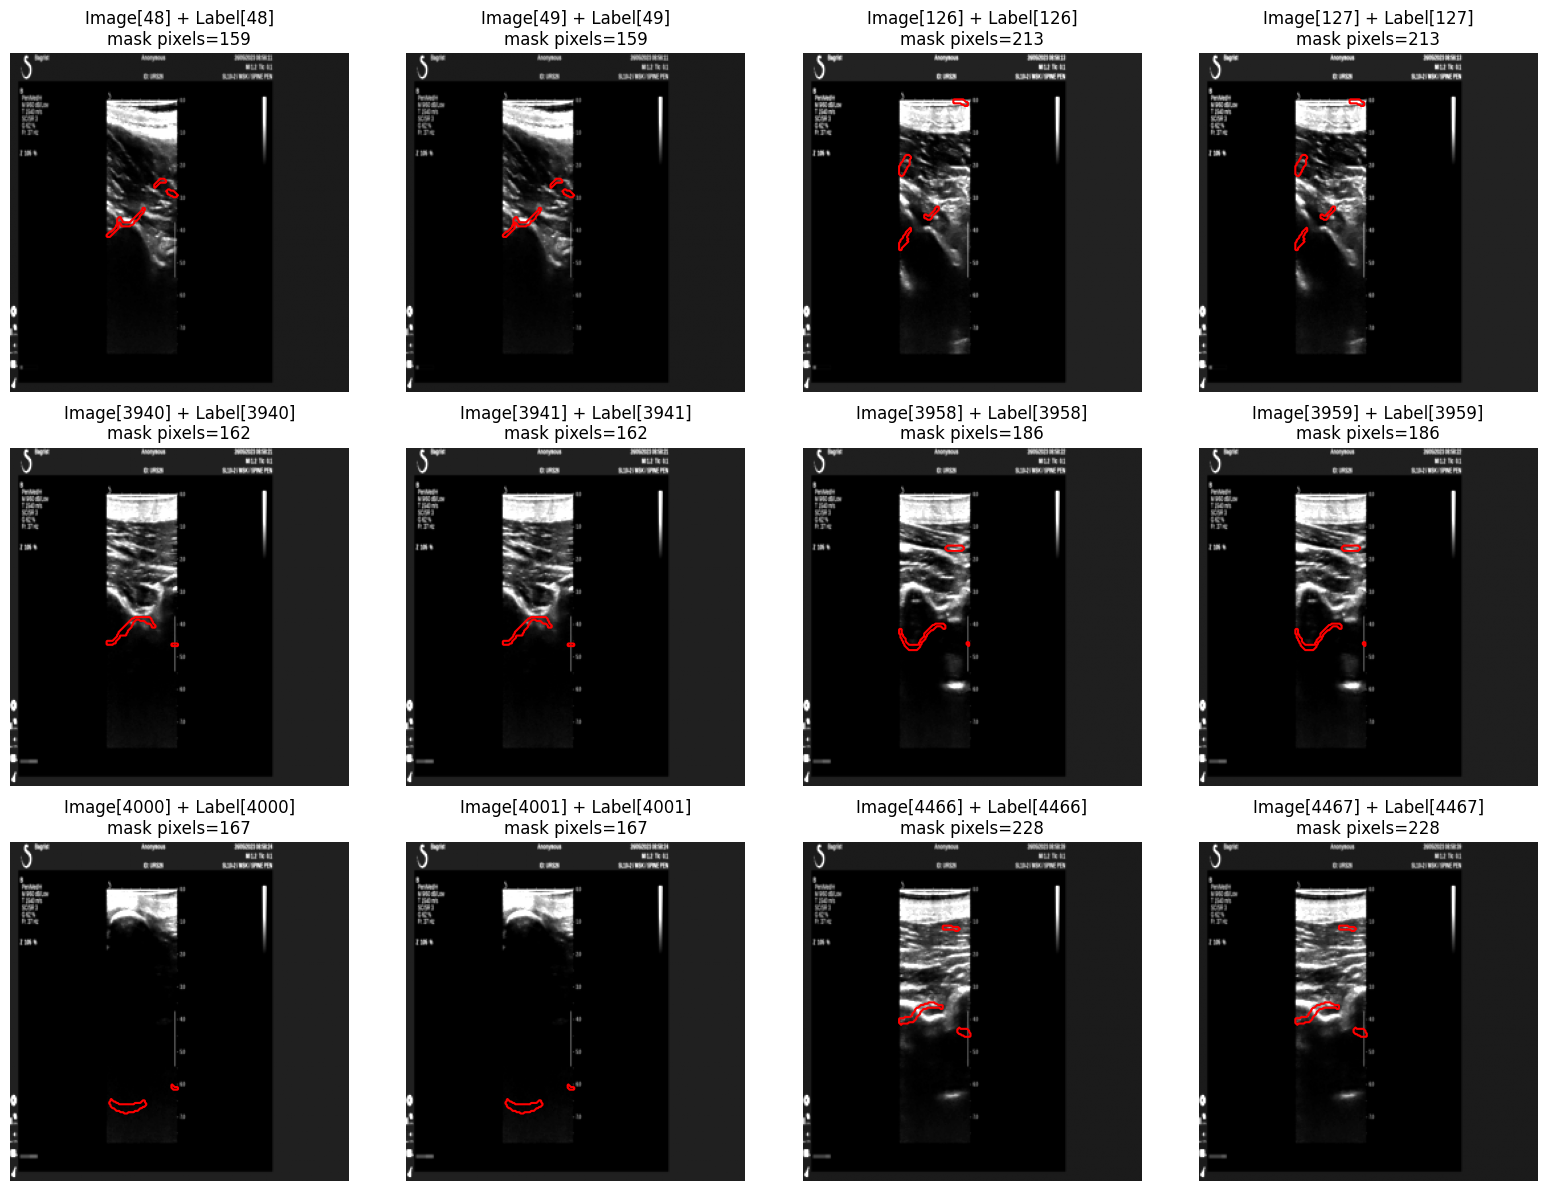

In [23]:
import numpy as np
import matplotlib.pyplot as plt

MASK_THRESHOLD = 0.5

# محاسبه chunked برای جلوگیری از مصرف زیاد RAM
mask_pixel_counts = np.zeros(
    labels.shape[0],
    dtype=np.int64,
)

chunk_size = 128

for start in range(0, labels.shape[0], chunk_size):
    end = min(
        start + chunk_size,
        labels.shape[0],
    )

    block = np.asarray(
        labels[start:end]
    )

    mask_pixel_counts[start:end] = (
        block >= MASK_THRESHOLD
    ).sum(axis=(1, 2))


# فریم‌هایی با بیشترین annotation
selected_frames = np.argsort(
    mask_pixel_counts
)[-12:]

selected_frames = np.sort(
    selected_frames
)

print("Selected frames:", selected_frames)
print(
    "Mask pixel counts:",
    mask_pixel_counts[selected_frames],
)


fig, axes = plt.subplots(
    3,
    4,
    figsize=(16, 12),
)

axes = axes.flatten()

for axis, frame_index in zip(
    axes,
    selected_frames,
):
    image = np.asarray(
        recordings[frame_index]
    )

    soft_mask = np.asarray(
        labels[frame_index]
    )

    binary_mask = (
        soft_mask >= MASK_THRESHOLD
    )

    vmin, vmax = np.percentile(
        image,
        [1, 99],
    )

    axis.imshow(
        image,
        cmap="gray",
        vmin=vmin,
        vmax=vmax,
    )

    if binary_mask.any():
        axis.contour(
            binary_mask.astype(float),
            levels=[0.5],
            colors="red",
            linewidths=1.5,
        )

    axis.set_title(
        f"Image[{frame_index}] + Label[{frame_index}]\n"
        f"mask pixels={binary_mask.sum()}"
    )

    axis.axis("off")

plt.tight_layout()
plt.show()

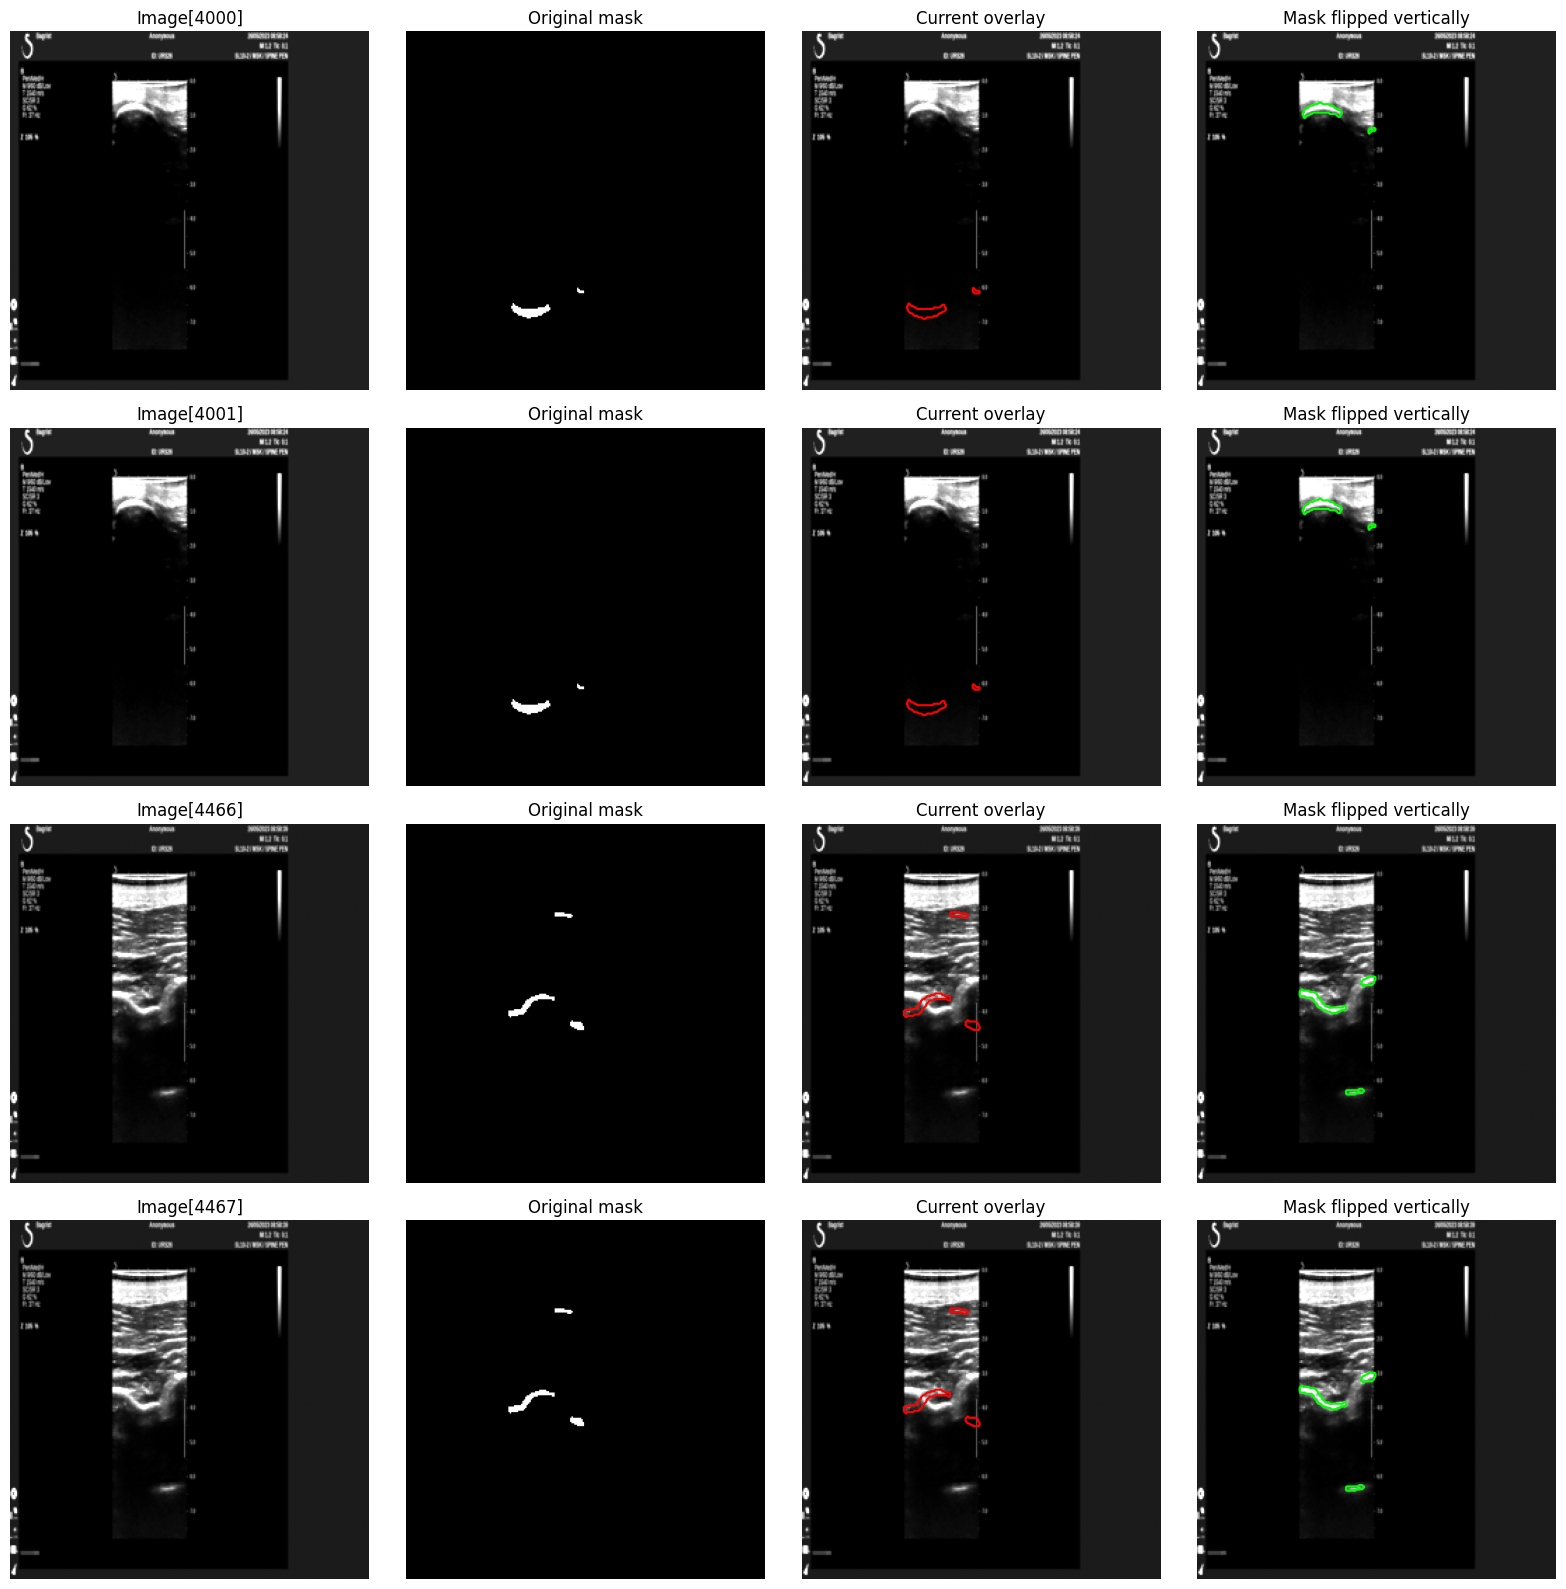

In [24]:
import numpy as np
import matplotlib.pyplot as plt

MASK_THRESHOLD = 0.5

selected_frames = [
    4000,
    4001,
    4466,
    4467,
]

fig, axes = plt.subplots(
    len(selected_frames),
    4,
    figsize=(16, 4 * len(selected_frames)),
)

for row, frame_index in enumerate(selected_frames):

    image = np.asarray(
        recordings[frame_index],
        dtype=np.float32,
    )

    soft_mask = np.asarray(
        labels[frame_index],
        dtype=np.float32,
    )

    original_mask = (
        soft_mask >= MASK_THRESHOLD
    )

    vertically_flipped_mask = np.flipud(
        original_mask
    )

    vmin, vmax = np.percentile(
        image,
        [1, 99],
    )

    # Original image
    axes[row, 0].imshow(
        image,
        cmap="gray",
        vmin=vmin,
        vmax=vmax,
    )
    axes[row, 0].set_title(
        f"Image[{frame_index}]"
    )

    # Mask alone before and after correction
    axes[row, 1].imshow(
        original_mask,
        cmap="gray",
        vmin=0,
        vmax=1,
    )
    axes[row, 1].set_title(
        "Original mask"
    )

    # Incorrect/current overlay
    axes[row, 2].imshow(
        image,
        cmap="gray",
        vmin=vmin,
        vmax=vmax,
    )

    if original_mask.any():
        axes[row, 2].contour(
            original_mask.astype(float),
            levels=[0.5],
            colors="red",
            linewidths=1.5,
        )

    axes[row, 2].set_title(
        "Current overlay"
    )

    # Vertically corrected overlay
    axes[row, 3].imshow(
        image,
        cmap="gray",
        vmin=vmin,
        vmax=vmax,
    )

    if vertically_flipped_mask.any():
        axes[row, 3].contour(
            vertically_flipped_mask.astype(float),
            levels=[0.5],
            colors="lime",
            linewidths=1.5,
        )

    axes[row, 3].set_title(
        "Mask flipped vertically"
    )

    for axis in axes[row]:
        axis.axis("off")

plt.tight_layout()
plt.show()

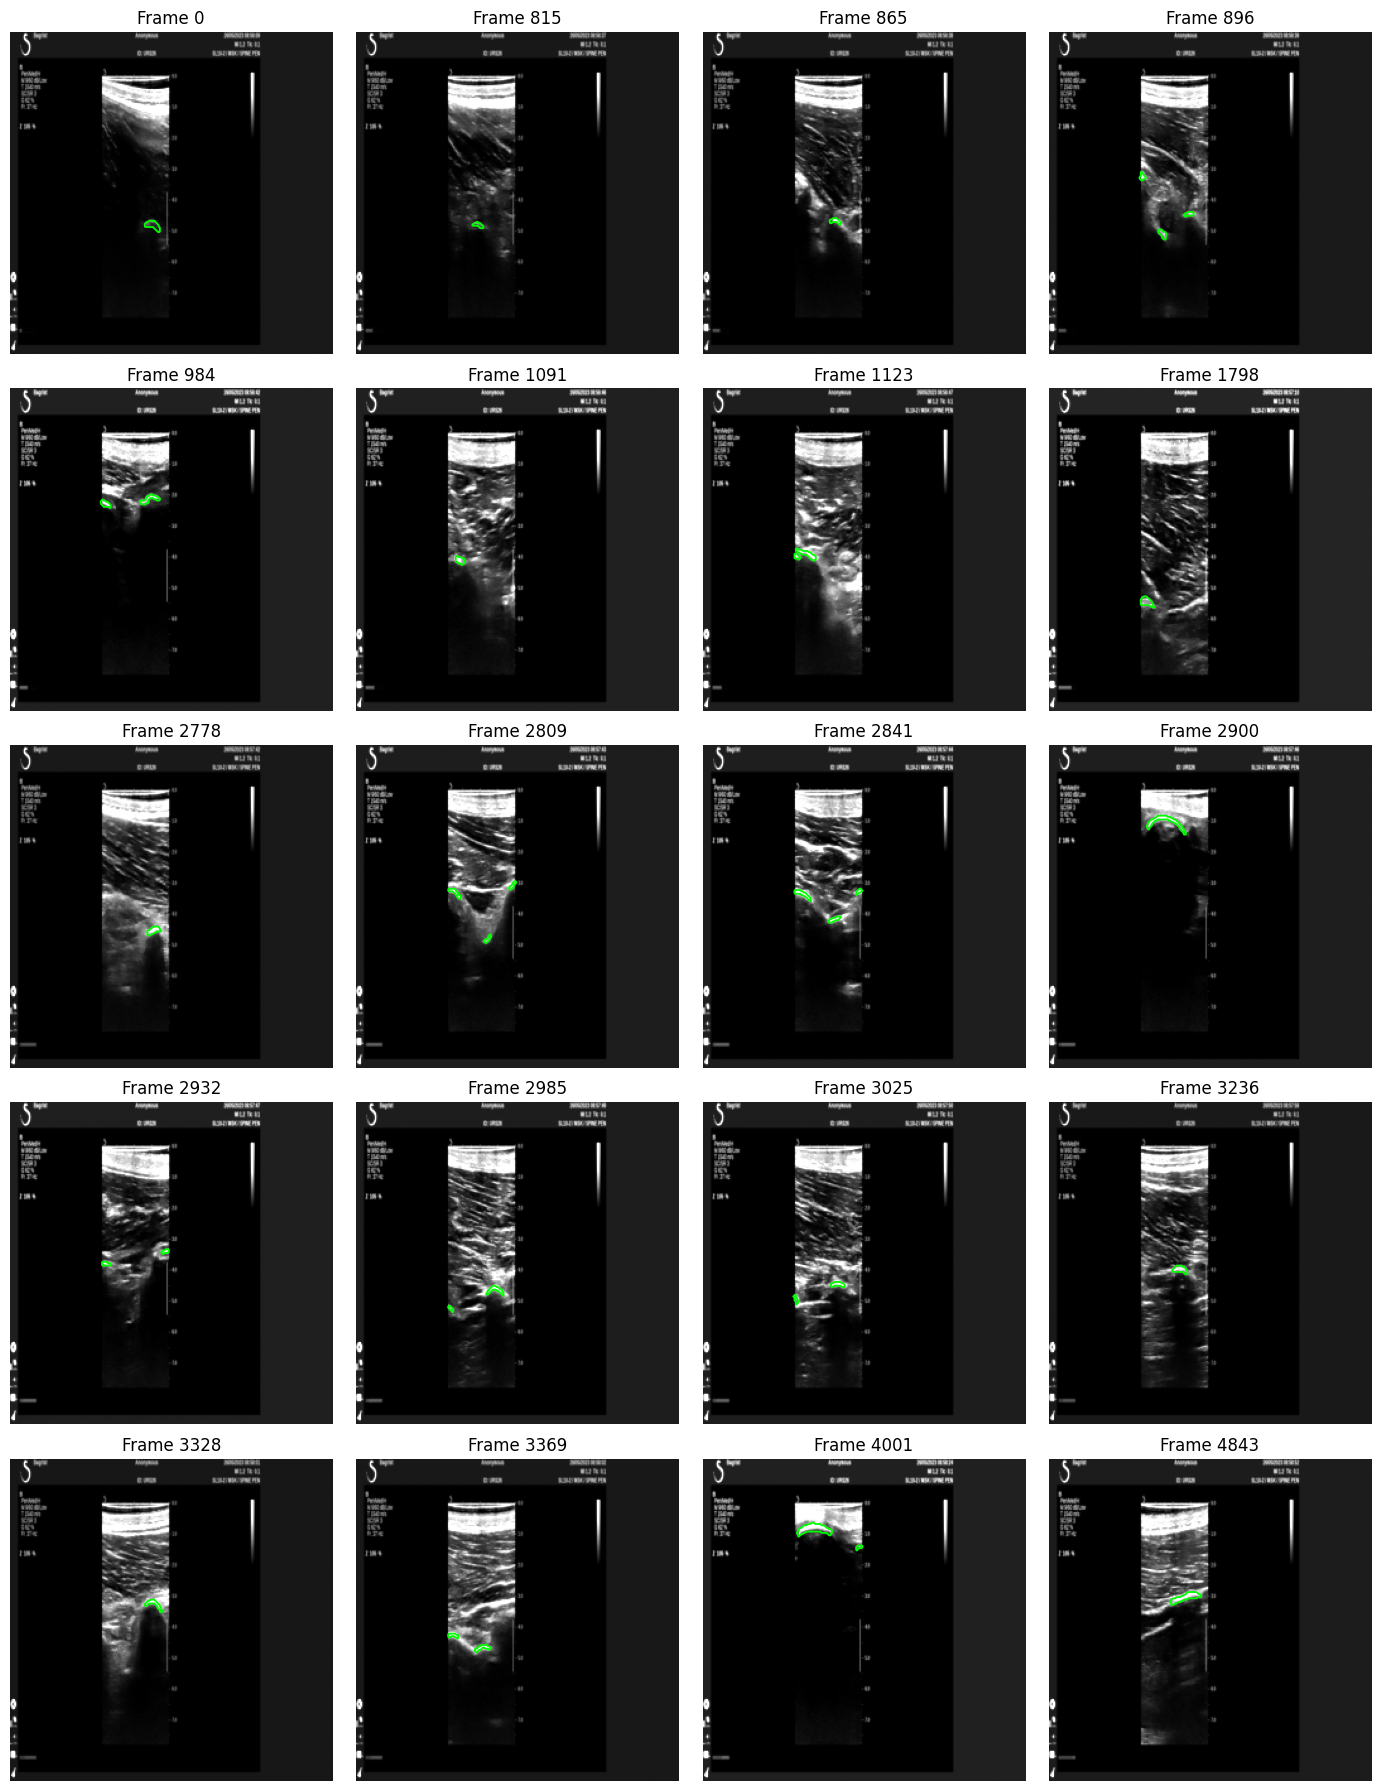

In [25]:
nonempty_indices = np.where(
    mask_pixel_counts > 0
)[0]

selected_positions = np.linspace(
    0,
    len(nonempty_indices) - 1,
    20,
    dtype=int,
)

selected_frames = nonempty_indices[
    selected_positions
]

fig, axes = plt.subplots(
    5,
    4,
    figsize=(14, 18),
)

for axis, frame_index in zip(
    axes.flatten(),
    selected_frames,
):

    image = np.asarray(
        recordings[frame_index],
        dtype=np.float32,
    )

    corrected_mask = np.flipud(
        np.asarray(labels[frame_index])
        >= MASK_THRESHOLD
    )

    vmin, vmax = np.percentile(
        image,
        [1, 99],
    )

    axis.imshow(
        image,
        cmap="gray",
        vmin=vmin,
        vmax=vmax,
    )

    if corrected_mask.any():
        axis.contour(
            corrected_mask.astype(float),
            levels=[0.5],
            colors="lime",
            linewidths=1.3,
        )

    axis.set_title(
        f"Frame {frame_index}"
    )
    axis.axis("off")

plt.tight_layout()
plt.show()

In [26]:
from pathlib import Path
import numpy as np

SUB26_DIR = Path(
    "/kaggle/input/datasets/amitismirabedini/sub26-data"
)

SUB26_RECORDINGS_PATH = (
    SUB26_DIR / "URS26_H3_recordings.npy"
)

SUB26_LABELS_PATH = (
    SUB26_DIR / "URS26_H3_labels.npy"
)

recordings_sub26 = np.load(
    SUB26_RECORDINGS_PATH,
    mmap_mode="r",
    allow_pickle=False,
)

labels_sub26 = np.load(
    SUB26_LABELS_PATH,
    mmap_mode="r",
    allow_pickle=False,
)

assert recordings_sub26.shape == labels_sub26.shape
assert recordings_sub26.ndim == 3
assert recordings_sub26.shape[1:] == (256, 256)

print("Recordings shape:", recordings_sub26.shape)
print("Labels shape:", labels_sub26.shape)
print("Recordings dtype:", recordings_sub26.dtype)
print("Labels dtype:", labels_sub26.dtype)

Recordings shape: (4972, 256, 256)
Labels shape: (4972, 256, 256)
Recordings dtype: float32
Labels dtype: float32


In [27]:
SUB26_MASK_THRESHOLD = 0.5


def load_sub26_frame(
    frame_index,
    mask_threshold=SUB26_MASK_THRESHOLD,
    return_soft_mask=False,
):
    """
    Returns:
        image:       float32, shape (256, 256, 1), range [0,1]
        binary_mask: float32, shape (256, 256, 1), values {0,1}

    If return_soft_mask=True, the vertically corrected soft mask
    is also returned.
    """

    if not 0 <= frame_index < len(recordings_sub26):
        raise IndexError(
            f"Frame index {frame_index} is outside "
            f"[0, {len(recordings_sub26) - 1}]"
        )

    # Already normalized to approximately [0,1]
    image = np.asarray(
        recordings_sub26[frame_index],
        dtype=np.float32,
    ).copy()

    # Read the corresponding soft mask
    soft_mask = np.asarray(
        labels_sub26[frame_index],
        dtype=np.float32,
    )

    # Correct the confirmed vertical orientation mismatch
    soft_mask = np.flip(
        soft_mask,
        axis=0,
    ).copy()

    image = np.clip(
        image,
        0.0,
        1.0,
    )

    binary_mask = (
        soft_mask >= mask_threshold
    ).astype(np.float32)

    # Add channel dimension
    image = image[..., None]
    binary_mask = binary_mask[..., None]
    soft_mask = soft_mask[..., None]

    assert image.shape == (256, 256, 1)
    assert binary_mask.shape == (256, 256, 1)
    assert np.isfinite(image).all()
    assert np.isfinite(binary_mask).all()
    assert set(np.unique(binary_mask)).issubset({0.0, 1.0})

    if return_soft_mask:
        return image, binary_mask, soft_mask

    return image, binary_mask

In [28]:
frame_index = 4000

image, mask, soft_mask = load_sub26_frame(
    frame_index,
    return_soft_mask=True,
)

print("Image shape:", image.shape)
print("Mask shape:", mask.shape)

print(
    "Image range:",
    image.min(),
    image.max(),
)

print(
    "Soft-mask range:",
    soft_mask.min(),
    soft_mask.max(),
)

print(
    "Binary-mask values:",
    np.unique(mask),
)

print(
    "Foreground pixels:",
    int(mask.sum()),
)

Image shape: (256, 256, 1)
Mask shape: (256, 256, 1)
Image range: 0.0627451 0.8627451
Soft-mask range: 0.0 1.0
Binary-mask values: [0. 1.]
Foreground pixels: 167


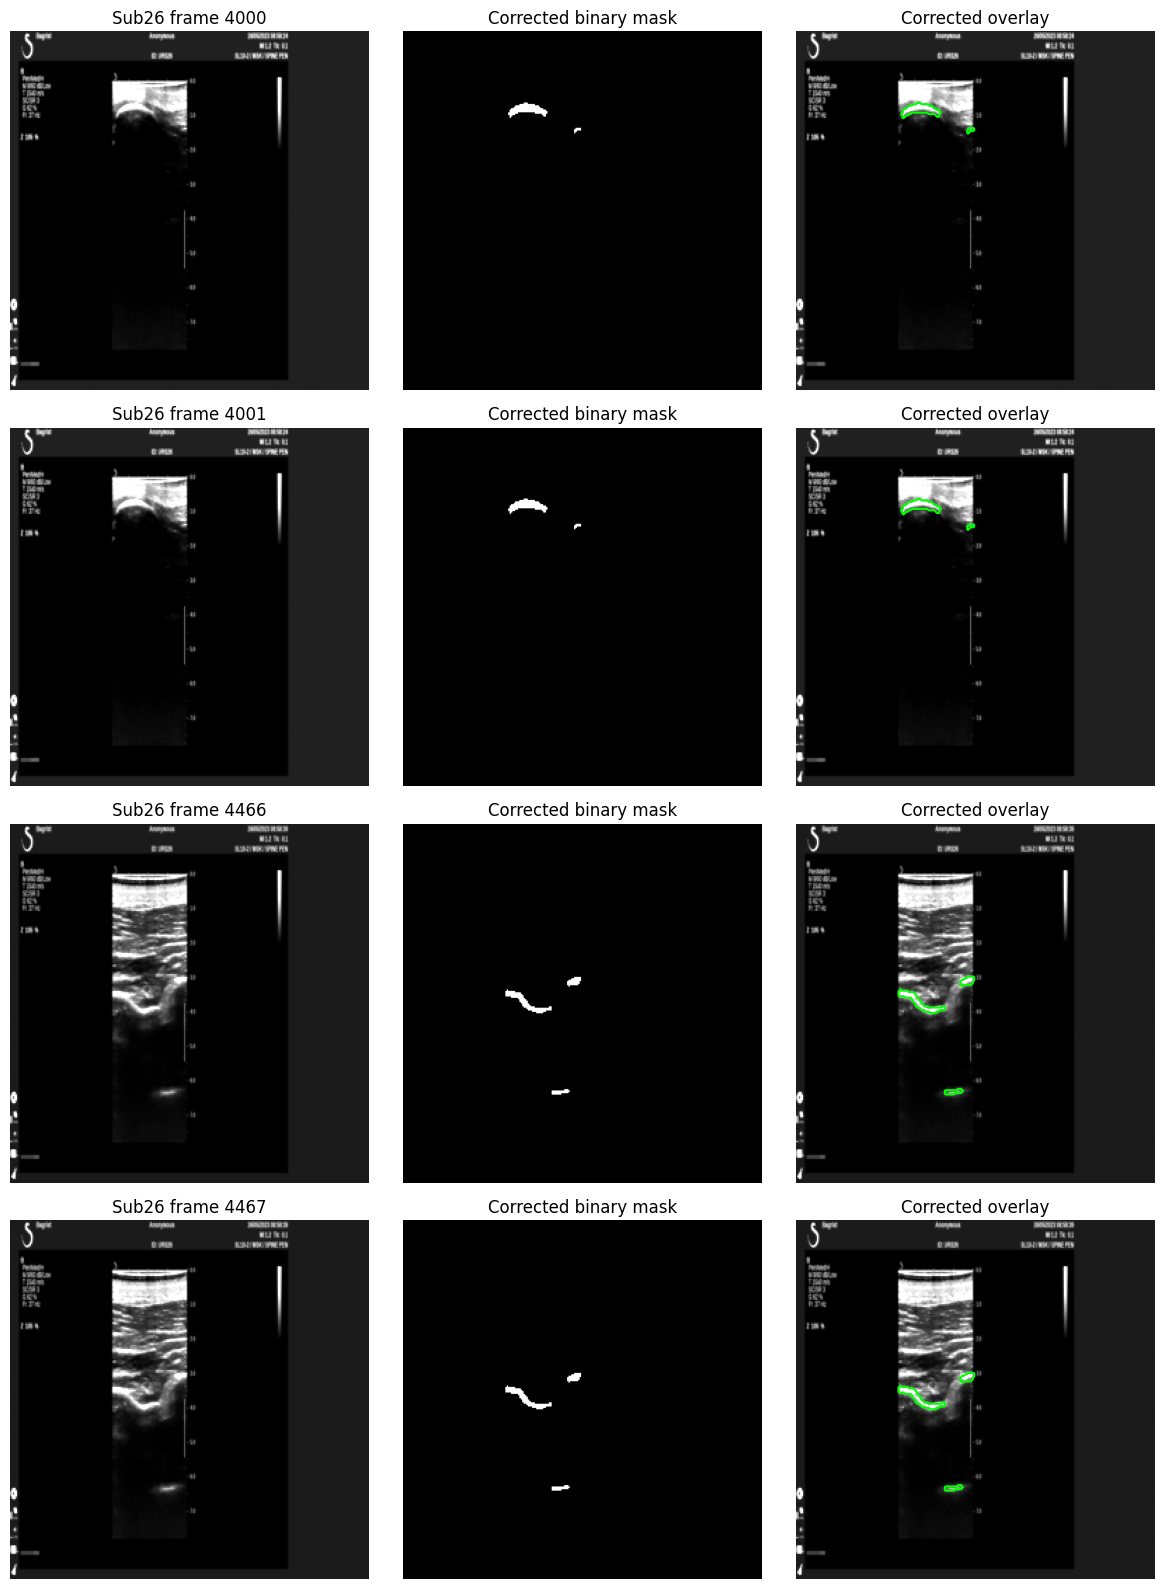

In [29]:
import matplotlib.pyplot as plt
import numpy as np

test_frames = [
    4000,
    4001,
    4466,
    4467,
]

fig, axes = plt.subplots(
    len(test_frames),
    3,
    figsize=(12, 4 * len(test_frames)),
)

for row, frame_index in enumerate(test_frames):

    image, mask = load_sub26_frame(
        frame_index
    )

    image = image[..., 0]
    mask = mask[..., 0].astype(bool)

    vmin, vmax = np.percentile(
        image,
        [1, 99],
    )

    axes[row, 0].imshow(
        image,
        cmap="gray",
        vmin=vmin,
        vmax=vmax,
    )
    axes[row, 0].set_title(
        f"Sub26 frame {frame_index}"
    )

    axes[row, 1].imshow(
        mask,
        cmap="gray",
        vmin=0,
        vmax=1,
    )
    axes[row, 1].set_title(
        "Corrected binary mask"
    )

    axes[row, 2].imshow(
        image,
        cmap="gray",
        vmin=vmin,
        vmax=vmax,
    )

    if mask.any():
        axes[row, 2].contour(
            mask.astype(float),
            levels=[0.5],
            colors="lime",
            linewidths=1.5,
        )

    axes[row, 2].set_title(
        "Corrected overlay"
    )

    for axis in axes[row]:
        axis.axis("off")

plt.tight_layout()
plt.show()

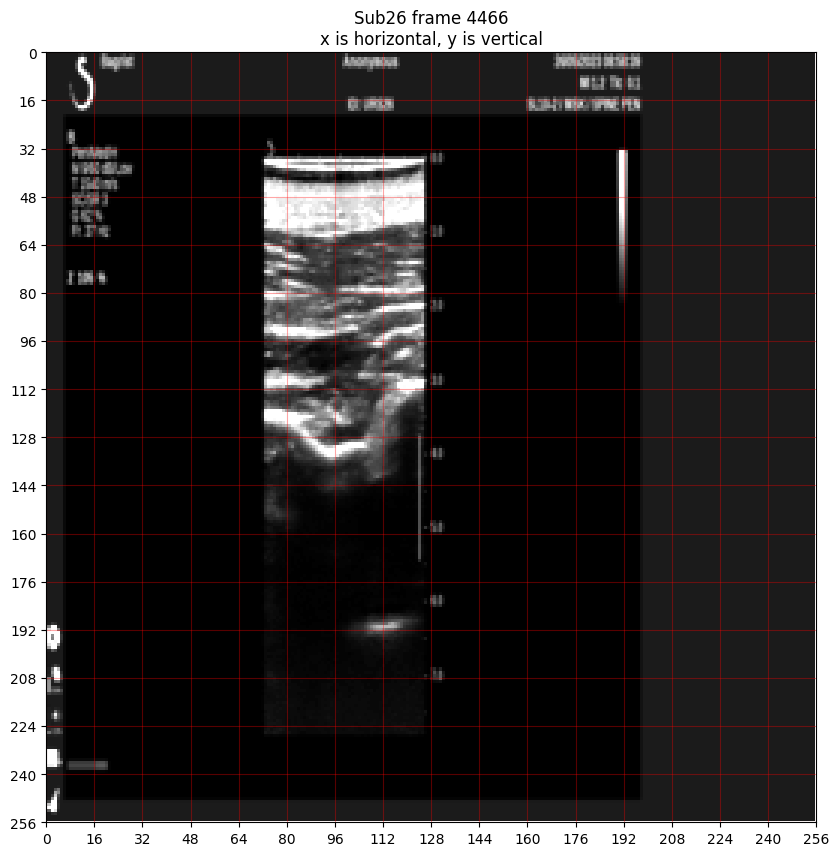

In [31]:
import numpy as np
import matplotlib.pyplot as plt

frame_index = 4466

image = np.asarray(
    recordings_sub26[frame_index],
    dtype=np.float32,
)

plt.figure(figsize=(10, 10))

plt.imshow(
    image,
    cmap="gray",
    vmin=np.percentile(image, 1),
    vmax=np.percentile(image, 99),
)

plt.xticks(
    np.arange(0, 257, 16)
)

plt.yticks(
    np.arange(0, 257, 16)
)

plt.grid(
    color="red",
    alpha=0.35,
)

plt.xlim(0, 256)
plt.ylim(256, 0)

plt.title(
    f"Sub26 frame {frame_index}\n"
    "x is horizontal, y is vertical"
)

plt.show()

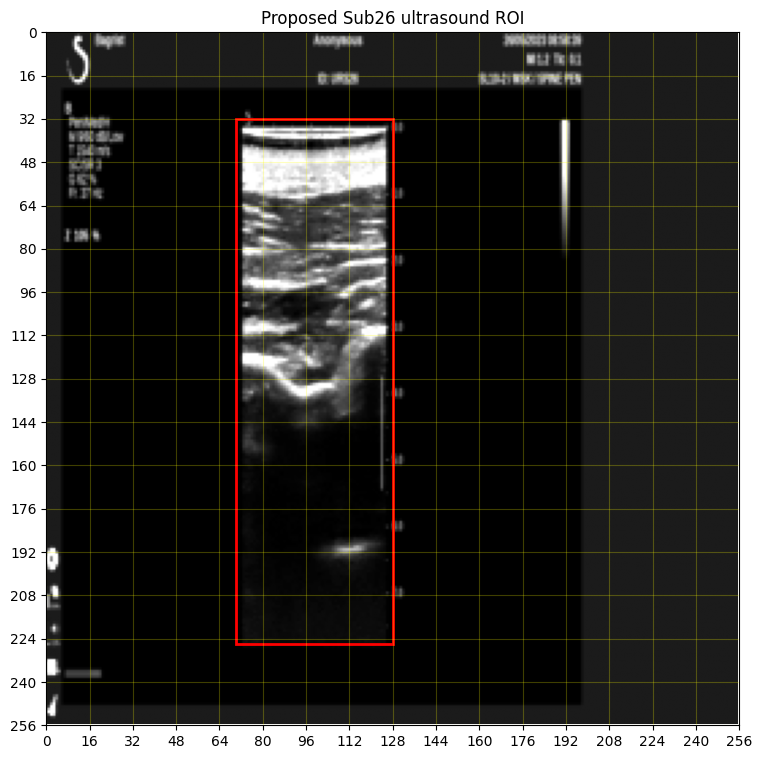

In [32]:
from matplotlib.patches import Rectangle
import matplotlib.pyplot as plt
import numpy as np

# Initial estimate — adjust after inspection
SUB26_X1 = 70
SUB26_X2 = 128

SUB26_Y1 = 32
SUB26_Y2 = 226

frame_index = 4466

image = np.asarray(
    recordings_sub26[frame_index],
    dtype=np.float32,
)

fig, axis = plt.subplots(
    figsize=(9, 9)
)

axis.imshow(
    image,
    cmap="gray",
    vmin=np.percentile(image, 1),
    vmax=np.percentile(image, 99),
)

rectangle = Rectangle(
    (SUB26_X1, SUB26_Y1),
    SUB26_X2 - SUB26_X1,
    SUB26_Y2 - SUB26_Y1,
    linewidth=2,
    edgecolor="red",
    facecolor="none",
)

axis.add_patch(rectangle)

axis.set_title(
    "Proposed Sub26 ultrasound ROI"
)

axis.set_xlim(0, 256)
axis.set_ylim(256, 0)
axis.set_xticks(np.arange(0, 257, 16))
axis.set_yticks(np.arange(0, 257, 16))
axis.grid(color="yellow", alpha=0.25)

plt.show()

### Final Preprocessing 

In [35]:
SUB26_MASK_THRESHOLD = 0.5

SUB26_CROP = {
    "x1": 70,
    "x2": 128,
    "y1": 32,
    "y2": 226,
}


def load_and_crop_sub26_frame(
    frame_index,
    threshold=SUB26_MASK_THRESHOLD,
    return_soft_mask=False,
):

    # -------------------------
    # Load original image
    # -------------------------

    image = np.asarray(
        recordings_sub26[frame_index],
        dtype=np.float32,
    ).copy()

    # Already normalized — do not divide by 255
    image = np.clip(
        image,
        0.0,
        1.0,
    )

    # -------------------------
    # Load and correct mask
    # -------------------------

    soft_mask = np.asarray(
        labels_sub26[frame_index],
        dtype=np.float32,
    )

    # Correct confirmed vertical flip
    soft_mask = np.flip(
        soft_mask,
        axis=0,
    ).copy()

    # -------------------------
    # Apply identical crop
    # -------------------------

    x1 = SUB26_CROP["x1"]
    x2 = SUB26_CROP["x2"]
    y1 = SUB26_CROP["y1"]
    y2 = SUB26_CROP["y2"]

    image_crop = image[
        y1:y2,
        x1:x2,
    ]

    soft_mask_crop = soft_mask[
        y1:y2,
        x1:x2,
    ]

    binary_mask_crop = (
        soft_mask_crop >= threshold
    ).astype(np.float32)

    # Add channel dimension
    image_crop = image_crop[..., None]
    soft_mask_crop = soft_mask_crop[..., None]
    binary_mask_crop = binary_mask_crop[..., None]

    assert image_crop.shape == binary_mask_crop.shape
    assert np.isfinite(image_crop).all()
    assert np.isfinite(binary_mask_crop).all()

    if return_soft_mask:
        return (
            image_crop,
            binary_mask_crop,
            soft_mask_crop,
        )

    return image_crop, binary_mask_crop

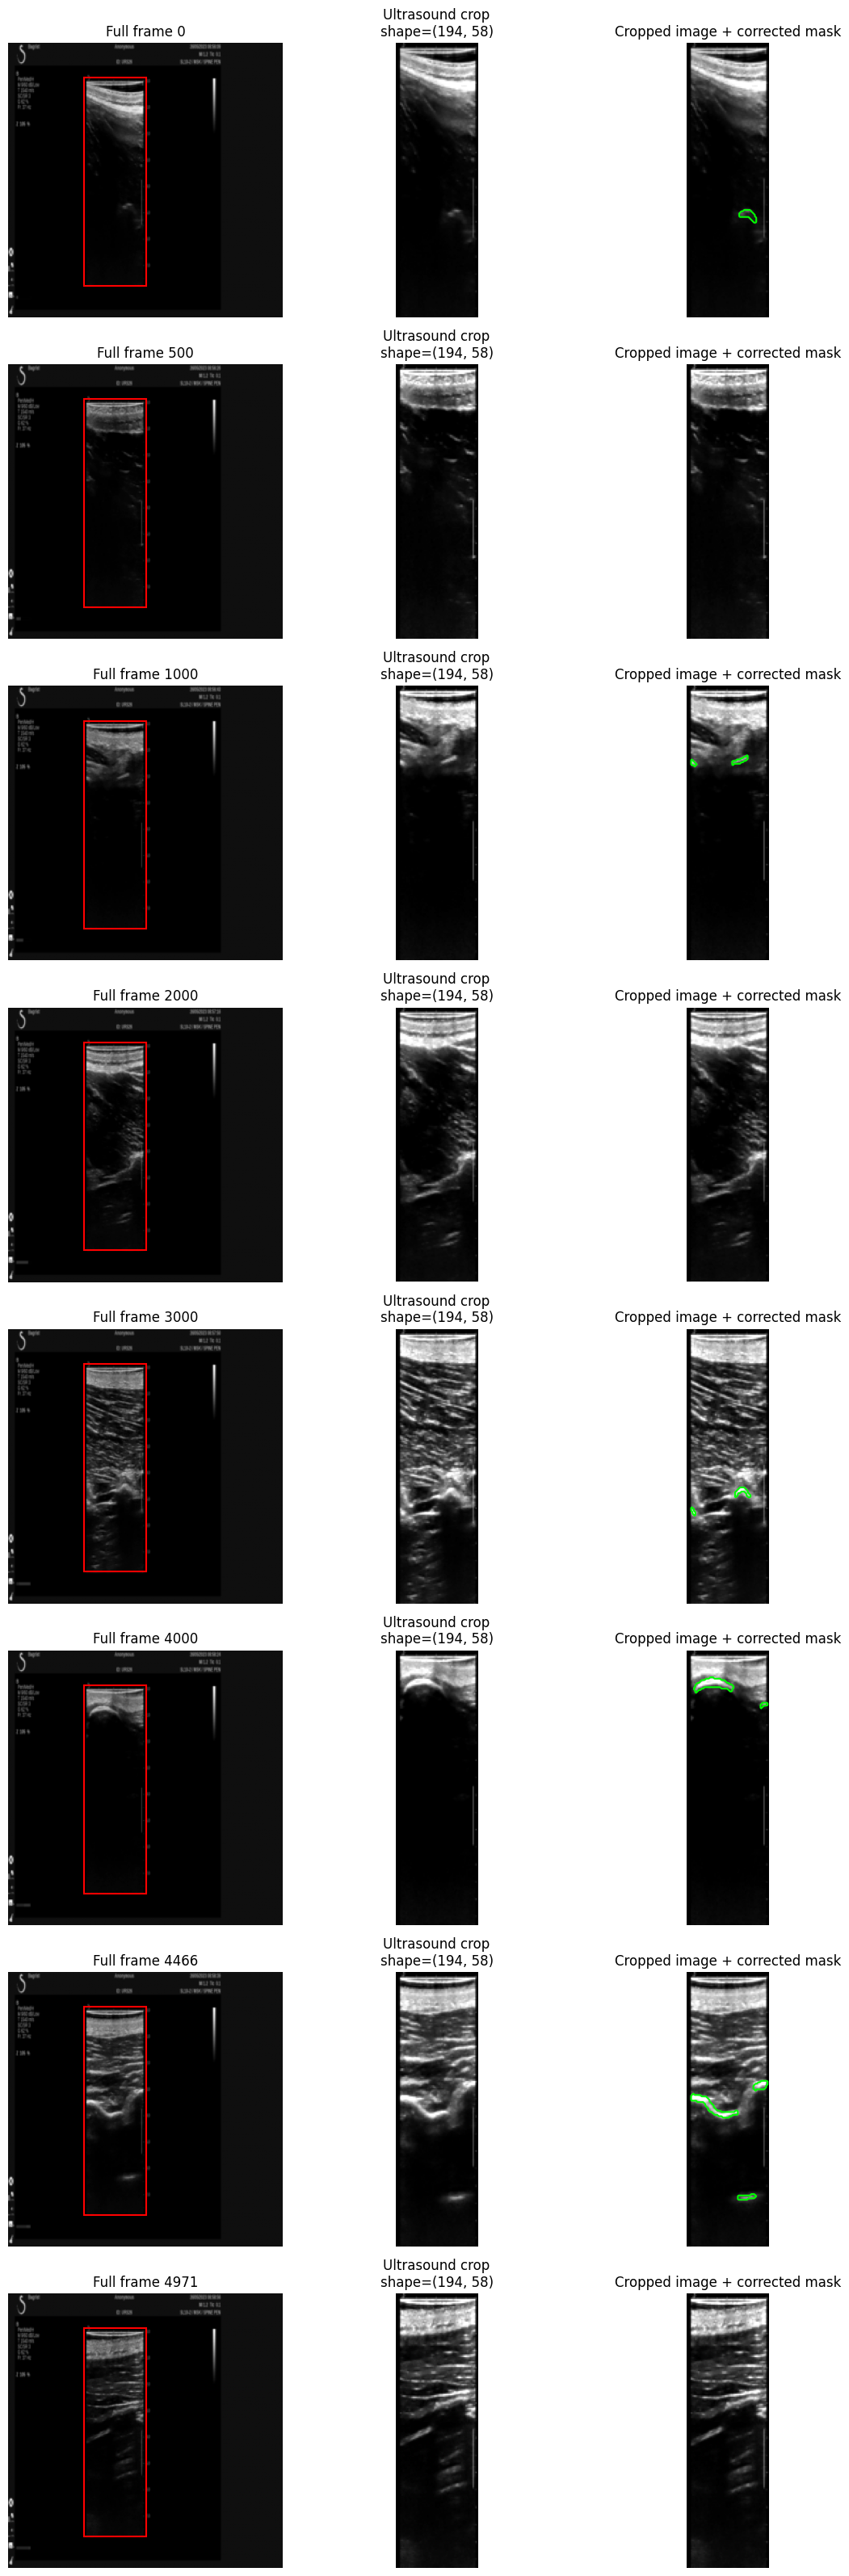

In [36]:
test_frames = [
    0,
    500,
    1000,
    2000,
    3000,
    4000,
    4466,
    4971,
]

fig, axes = plt.subplots(
    len(test_frames),
    3,
    figsize=(12, 4 * len(test_frames)),
)

for row, frame_index in enumerate(test_frames):

    full_image = np.asarray(
        recordings_sub26[frame_index],
        dtype=np.float32,
    )

    cropped_image, cropped_mask = (
        load_and_crop_sub26_frame(
            frame_index
        )
    )

    cropped_image = cropped_image[..., 0]
    cropped_mask = cropped_mask[..., 0].astype(bool)

    # Full image
    axes[row, 0].imshow(
        full_image,
        cmap="gray",
    )

    axes[row, 0].add_patch(
        Rectangle(
            (
                SUB26_CROP["x1"],
                SUB26_CROP["y1"],
            ),
            SUB26_CROP["x2"] - SUB26_CROP["x1"],
            SUB26_CROP["y2"] - SUB26_CROP["y1"],
            linewidth=1.5,
            edgecolor="red",
            facecolor="none",
        )
    )

    axes[row, 0].set_title(
        f"Full frame {frame_index}"
    )

    # Cropped image
    axes[row, 1].imshow(
        cropped_image,
        cmap="gray",
        vmin=np.percentile(cropped_image, 1),
        vmax=np.percentile(cropped_image, 99),
    )

    axes[row, 1].set_title(
        f"Ultrasound crop\n"
        f"shape={cropped_image.shape}"
    )

    # Cropped overlay
    axes[row, 2].imshow(
        cropped_image,
        cmap="gray",
        vmin=np.percentile(cropped_image, 1),
        vmax=np.percentile(cropped_image, 99),
    )

    if cropped_mask.any():
        axes[row, 2].contour(
            cropped_mask.astype(float),
            levels=[0.5],
            colors="lime",
            linewidths=1.5,
        )

    axes[row, 2].set_title(
        "Cropped image + corrected mask"
    )

    for axis in axes[row]:
        axis.axis("off")

plt.tight_layout()
plt.show()